In [1]:
import functools
import os
home = os.environ['HOME']
import warnings

from flax.training import checkpoints
from paltax import train, train_snpe
from paltax import models
from paltax import input_pipeline
import jax.numpy as jnp
import jax
import numpy as np

from paltax.TrainConfigs import train_config_snpe_weighted
from paltax.TrainConfigs import train_config_snpe_base
from paltax import source_models
warnings.filterwarnings('ignore')

# These are identical except for the source_model which is CosmosCatalog for base and WeightedCatalog for weighted
# But we want to use CosmosCatalog here to easily iterate over the galaxy indices
weighted_config = train_config_snpe_weighted.get_config()
base_config = train_config_snpe_base.get_config()

config = base_config
input_config = train._get_config(config.input_config_path)
cosmos_path = home + '/weighted_catalog_training.h5'
input_config['all_models']['all_source_models'] = (source_models.CosmosCatalog(cosmos_path,2163),)
assert input_config['all_models']['all_source_models'][0].images_per_chunk == 2163

image_size = input_config['kwargs_detector']['n_x']

# The number of gpus used in training which effectively multiplies the number of images per
# step through the pmap
n_gpus_train = 4

2025-02-24 11:49:15.050335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740426555.067014  996766 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740426555.072037  996766 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
rng = jax.random.PRNGKey(0)
learning_rate = 1e-2
learning_rate_schedule = train_snpe.get_learning_rate_schedule(config, learning_rate)

model50 = models.ResNet50(num_outputs=len(input_config['truth_parameters'][0]) * 2, dtype=jnp.float32)
state50 = train.create_train_state(rng, config, model50, image_size, learning_rate_schedule)

In [3]:
# Fiducial or Sequential
network_model = "Sequential"

if network_model == "Fiducial":
    model_dirs = [home + '/fr_5M_new']
    num_epochs_train = 200
elif network_model == "Sequential":
    model_dirs = [home + '/image_0']
    num_epochs_train = 40

steps_snpe = np.arange(1,num_epochs_train+1) * config.steps_per_epoch #3900 steps per epoch

states = [state50]
train_strings = ['Image 0']

# Load model state at 40 epochs
model_dir = model_dirs[0]
state = state50

for step in steps_snpe:
    state = checkpoints.restore_checkpoint(model_dir, state, step=step)

In [4]:
draw_image_and_truth_vmap = jax.jit(jax.vmap(
        functools.partial(
            input_pipeline.draw_image_and_truth,
            all_models=input_config['all_models'],
            principal_model_indices=input_config['principal_model_indices'],
            kwargs_simulation=input_config['kwargs_simulation'],
            kwargs_detector=input_config['kwargs_detector'],
            kwargs_psf=input_config['kwargs_psf'],
            truth_parameters=input_config['truth_parameters'],
            normalize_config=input_config['lensing_config']),
        in_axes=(None, None, None, None, 0, None)))
cosmology_params = input_pipeline.initialize_cosmology_params(input_config, rng)
grid_x, grid_y = input_pipeline.generate_grids(input_config)

In [5]:
@jax.jit
def get_outputs(state, image):
    return state.apply_fn({'params': state.params, 'batch_stats': state.batch_stats}, 
                          jnp.expand_dims(image, axis=-1), train=False, mutable=False)

@jax.jit
def compute_rmse(outputs, truth):
    mean, _ = jnp.split(outputs, 2, axis=-1)
    rmse_per_param = jnp.sqrt(jnp.mean(jnp.square(mean - truth), axis=0))
    metrics = {
        'rmse_per_param': rmse_per_param
    }
    return metrics

@jax.jit
def compute_rho(outputs, truth):
    mean, _ = jnp.split(outputs, 2, axis=-1)
    rho_per_param = jnp.corrcoef(mean.T, truth.T)[[0,1,2,3,4],[5,6,7,8,9]]
    metrics = {
        'rho_per_param': rho_per_param
    }
    return metrics

def Pearson_correlation(X,Y):
	X = np.array(X)
	Y = np.array(Y)
	if len(X)==len(Y):
		Sum_xy = sum((X-X.mean())*(Y-Y.mean()))
		Sum_x_squared = sum((X-X.mean())**2)
		Sum_y_squared = sum((Y-Y.mean())**2)	 
		corr = Sum_xy / np.sqrt(Sum_x_squared * Sum_y_squared)
	else:
		raise ValueError(f"x and y must be of the same size. x has size {X.size} and y has size {Y.size}")
	return corr

def rms_spread(y):
      y = np.array(y)
      y_mean = np.ones_like(y) * np.average(y)
      return np.sqrt(np.average((y-y_mean)**2))

In [6]:
# Load up the encodings used to train the model to calculate the apt loss normalized to the 
# distribution used to train the NPE model.
mu_prior = config.mu_prior
prec_prior = config.prec_prior

mu_prop_init = config.mu_prop_init
prec_prop_init = config.prec_prop_init
std_prop_init = jnp.power(jnp.diag(prec_prop_init), -0.5)

prop_encoding = jax.vmap(input_pipeline.encode_normal)(
        mu_prop_init, std_prop_init
)

In [7]:
image_hier = []
truth_hier = []

image_hier.append(np.load(home + '/image_0.npy'))
truth_hier.append(np.load(home + '/truth_0.npy'))

image_hier = jnp.stack(image_hier, axis=0)
truth_hier = jnp.stack(truth_hier, axis=0)

mean_metrics = {}
log_var_metrics = {}
log_post_metrics = {}
log_post_theta_e_metrics = {}
log_post_ss_metrics = {}

## Running the model with various input configurations to test the dependence of sigma sub predictions vs morphological parameters

In [8]:
input_config_test = train._get_config(config.input_config_path)
input_config_test['all_models']['all_source_models'] = (source_models.CosmosCatalog(cosmos_path,2163),)
assert input_config_test['all_models']['all_source_models'][0].images_per_chunk == 2163

std_norm = config.std_norm
mean_norm = config.mean_norm

mu_test_unormalized = truth_hier[0] * std_norm + mean_norm
std_test_unormalized = std_norm * 0.01

for truth_i in range(len(input_config_test['truth_parameters'][0])):
    rewrite_object = input_config_test['truth_parameters'][0][truth_i]
    rewrite_key = input_config_test['truth_parameters'][1][truth_i]
    input_config_test['lensing_config'][rewrite_object][rewrite_key] = input_pipeline.encode_constant(
        mu_test_unormalized[truth_i])

galaxy_index_list = []

source_morphology_params_list = {}

# These paramaters change with galaxy index, i.e. they are the same across all realizations for the same source
parameters = ['asymmetry', 'axial_ratio', 'concpetro', 'gini', 'm20', 'rhalfreal', 'rpetroreal', 'redshifts']
# These parameters change across different realizations for the same source
realization_parameters = ['amp', 'angle', 'center_x', 'center_y']

for parameter in parameters + realization_parameters:
    source_morphology_params_list[parameter] = []

ss_avg_list = []
ss_avg_variance_list = []

In [10]:
print("galaxy_index_list:", galaxy_index_list)
print("source_morphology_params:", source_morphology_params_list)
print("ss_avg_list:", ss_avg_list)
print("ss_avg_variance_list:", ss_avg_variance_list)

galaxy_index_list: []
source_morphology_params: {'asymmetry': [], 'axial_ratio': [], 'concpetro': [], 'gini': [], 'm20': [], 'rhalfreal': [], 'rpetroreal': [], 'redshift': [], 'amp': [], 'angle': [], 'center_x': [], 'center_y': []}
ss_avg_list: []
ss_avg_variance_list: []


In [ ]:
# Use the same rng seed each time
rng = jax.random.PRNGKey(0)
_rng, _ = jax.random.split(rng)
rng_images = jax.random.split(_rng, 100)

for galaxy_num in range(2163):

    input_config_test['lensing_config']['source_params']['galaxy_index'] = input_pipeline.encode_constant(galaxy_num/2163.)
    #input_config_test['lensing_config']['source_params']['amp'] = input_pipeline.encode_constant(1.3)
    #input_config_test['lensing_config']['source_params']['amp'] = input_pipeline.encode_uniform(minimum=0.5, maximum=2.0)
    #input_config_test['lensing_config']['source_params']['angle'] = input_pipeline.encode_constant(jnp.pi) 
    #input_config_test['lensing_config']['source_params']['angle'] = input_pipeline.encode_uniform(minimum=0.0, maximum=2 * jnp.pi)
    #input_config_test['lensing_config']['source_params']['center_x'] = input_pipeline.encode_normal(mean=center_x_truth, std=0.05) 
    #input_config_test['lensing_config']['source_params']['center_y'] = input_pipeline.encode_normal(mean=center_y_truth, std=0.05) 


    im, t, source_morphology_params, galaxy_index = draw_image_and_truth_vmap(input_config_test['lensing_config'], cosmology_params, grid_x,
                                             grid_y, rng_images, 0.0)
    
    galaxy_index_list.append(galaxy_index[0].item())

    # These paramaters change with galaxy index, i.e. they're the same across all realizations of the same source
    for parameter in parameters:
        source_morphology_params_list[parameter].append(source_morphology_params[parameter][0].item())
        
    # These parameters change across realizations of the same source
    for parameter in realization_parameters:
        source_morphology_params_list[parameter].append(source_morphology_params[parameter][0].reshape(-1))
    
    outputs_hr = get_outputs(state, im)
    mean_hr, log_var_hr = jnp.split(outputs_hr, 2, axis=-1)

    ss_predictions = mean_hr[:, [10]].reshape(-1)

    ss_log_variances = log_var_hr[:, [10]].reshape(-1)
    ss_variances = np.exp(ss_log_variances)

    # calculate the average sigma sub using inverse variance weighted average
    ss_avg_variance = 1./np.sum(1./ss_variances)
    ss_avg = np.sum(ss_predictions/ss_variances) * ss_avg_variance

    ss_avg_list.append(ss_avg)
    ss_avg_variance_list.append(ss_avg_variance)

ss_avg_list = np.array(ss_avg_list)
ss_avg_variance_list = np.array(ss_avg_variance_list)
with open(home + r'/ss_avg_list_sequential_40epochs.npy', 'wb') as file:
    np.save(file, ss_avg_list)
    
with open(home + r'/ss_avg_variance_list_sequential_40epochs.npy', 'wb') as file:
    np.save(file, ss_avg_variance_list)

In [ ]:
import os
import numpy as np
home = os.environ['HOME']
import h5py

parameters = ['asymmetry', 'axial_ratio', 'concpetro', 'gini', 'm20', 'rhalfreal', 'rpetroreal', 'redshifts']
source_morphology_params_list = {}

with open(home + r'/ss_avg_list_sequential_40epochs.npy', 'rb') as file:
    ss_avg_list = np.load(file)

galaxy_image_list = []

with h5py.File(home + r'/weighted_catalog_training.h5', 'r') as file:
    print(file.keys())
    for parameter in parameters:
        source_morphology_params_list[parameter] = file[parameter][:]
    galaxy_image_list.append(file['images'][:])
print(source_morphology_params_list)

galaxy_index_list = np.linspace(0, 2162, 2163, dtype=int)

<KeysViewHDF5 ['asymmetry', 'asymmetry_weights', 'axial_ratio', 'axial_ratio_weights', 'concpetro', 'concpetro_weights', 'gini', 'gini_weights', 'images', 'm20', 'm20_weights', 'pixel_sizes', 'redshifts', 'rhalfreal', 'rhalfreal_weights', 'rpetroreal', 'rpetroreal_weights']>
{'asymmetry': array([0.009, 0.113, 0.017, ..., 0.08 , 0.134, 0.09 ]), 'axial_ratio': array([0.526, 0.631, 0.851, ..., 0.529, 0.263, 0.872]), 'concpetro': array([4.54     , 3.803    , 4.6690001, ..., 3.8710001, 3.6989999,
       3.424    ]), 'gini': array([0.61 , 0.585, 0.612, ..., 0.57 , 0.569, 0.5  ]), 'm20': array([-2.52     , -1.997    , -2.5699999, ..., -2.3080001, -2.4260001,
       -2.056    ]), 'rhalfreal': array([0.00135018, 0.00255866, 0.0017679 , ..., 0.0026634 , 0.00215386,
       0.00274635]), 'rpetroreal': array([0.00393005, 0.00657093, 0.00529439, ..., 0.00748701, 0.00574215,
       0.00600403]), 'redshift': array([0.105     , 0.103     , 0.081     , ..., 0.359     , 0.30000001,
       0.3407    ], dt

correlation coefficient: 0.047232838941198195


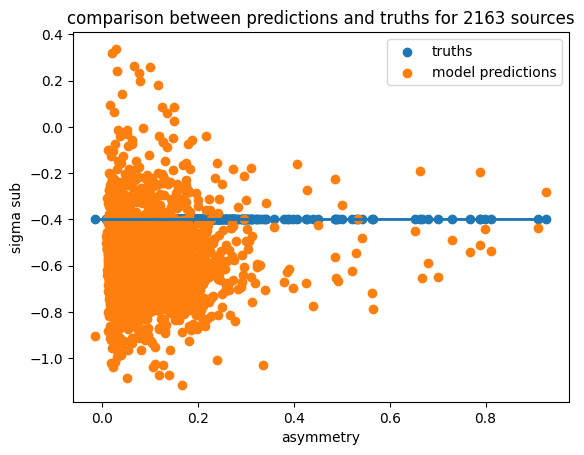

correlation coefficient: -0.041393473555754935


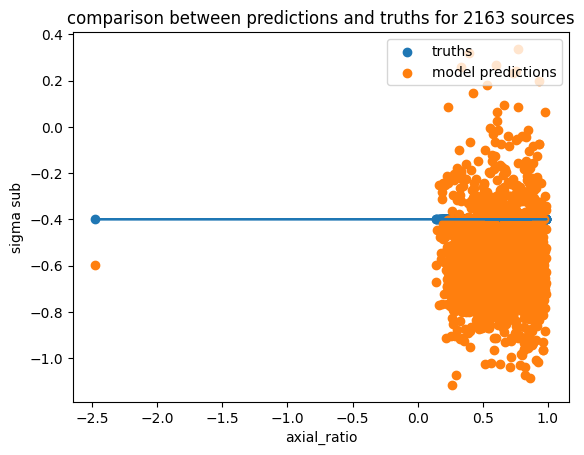

correlation coefficient: -0.02101777737256859


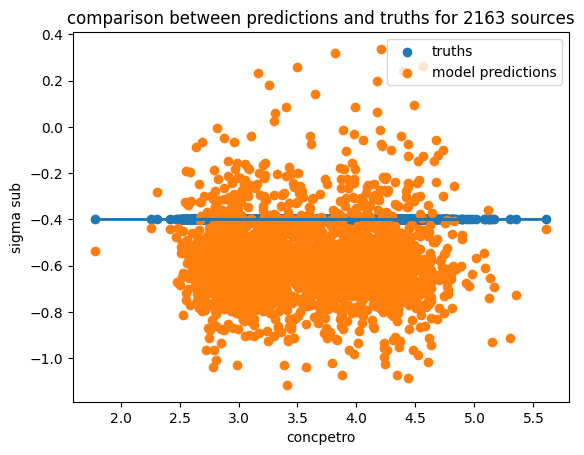

correlation coefficient: 0.004433335923387594


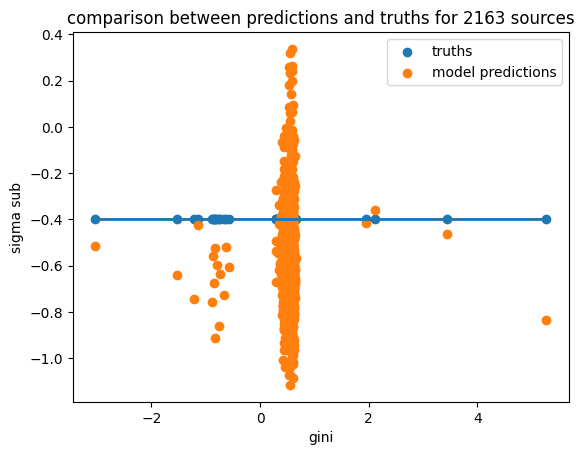

correlation coefficient: 0.019819687032181274


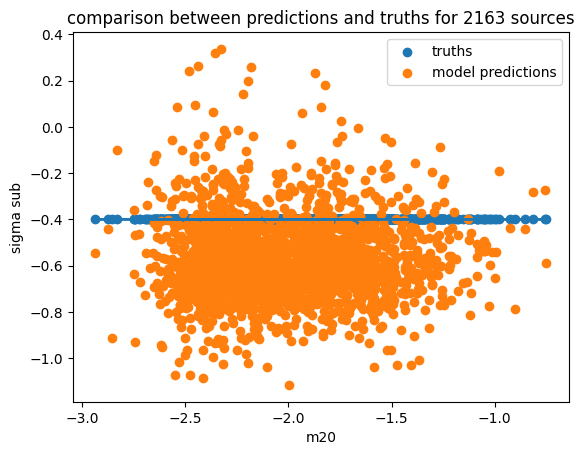

correlation coefficient: -0.06583601289450168


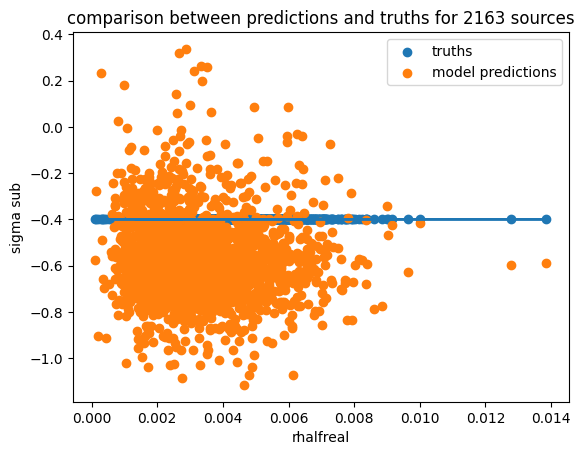

correlation coefficient: -0.07282110463044729


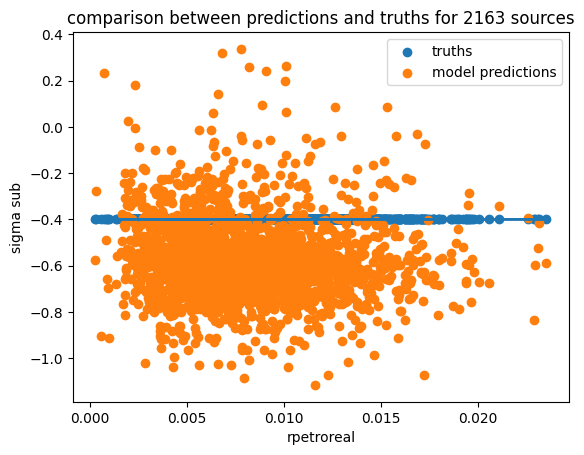

correlation coefficient: -0.016466862807519165


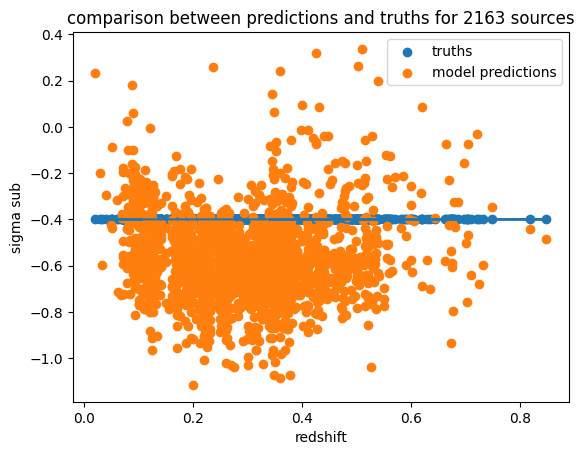

In [ ]:
import matplotlib.pyplot as plt

parameters = ['asymmetry', 'axial_ratio', 'concpetro', 'gini', 'm20', 'rhalfreal', 'rpetroreal', 'redshifts']

y_truth = np.ones_like(ss_avg_list) * truth_hier[0][-1]
y = np.array(ss_avg_list)
#y_err = np.sqrt(ss_avg_variance_list)

for i in range(8):
    x = source_morphology_params_list[parameters[i]][:len(y)]
    corr = Pearson_correlation(x, y)
    print("correlation coefficient:", corr)
	
    plt.title(f"comparison between predictions and truths for {len(x)} sources")
    plt.xlabel(parameters[i])
    plt.ylabel("sigma sub")

    plt.scatter(x, y_truth)
    plt.errorbar(x, y_truth, xerr=None, yerr=None)

    plt.scatter(x, y)
    plt.errorbar(x, y, xerr=None, yerr=None, ls='none')

    plt.legend(["truths", "model predictions"], fontsize=10, loc='upper right')

    plt.show()

dict_keys(['asymmetry', 'axial_ratio', 'concpetro', 'gini', 'm20', 'rhalfreal', 'rpetroreal', 'redshift', 'sigma_sub'])
(1500, 9)


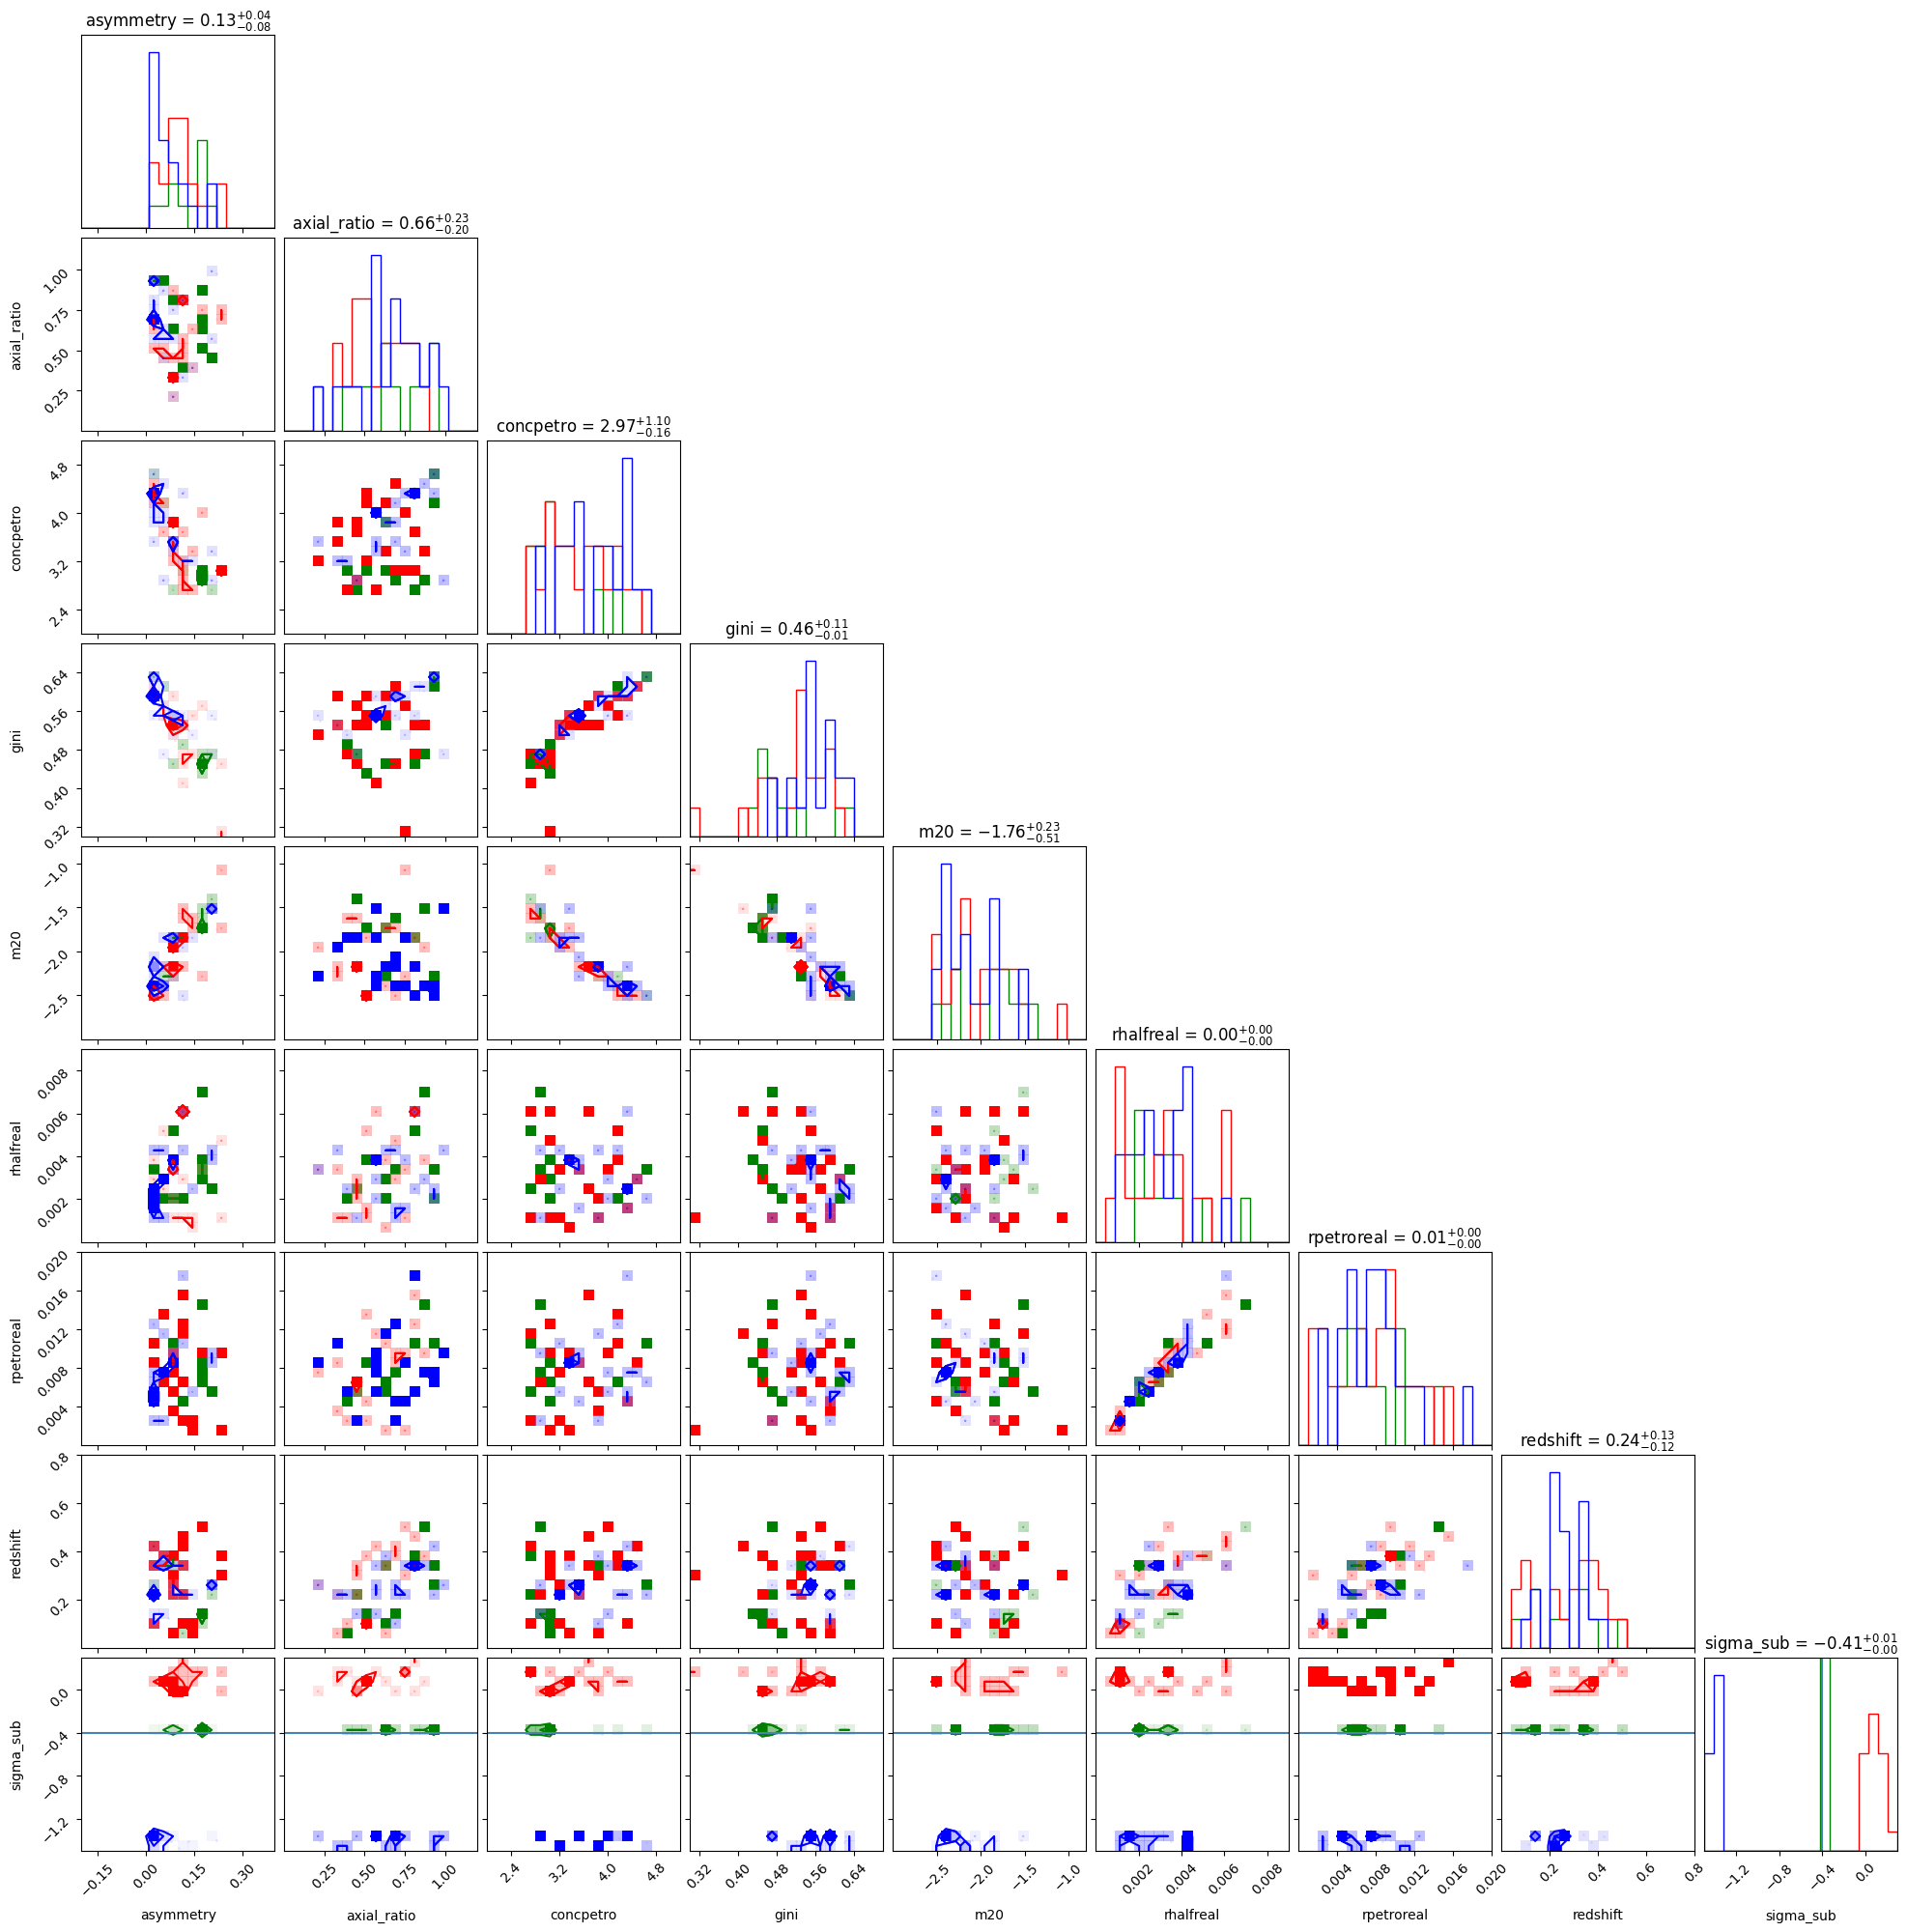

In [12]:
import corner
import copy

params = copy.deepcopy(source_morphology_params_list)
params['sigma_sub'] = ss_avg_list
print(params.keys())

data = np.array([np.array(params['asymmetry'])[ss_avg_list.argsort()]])
for key in params.keys():
    if key == 'asymmetry':
        continue
    params[key] = np.array(params[key])
    data = np.concatenate([data, [params[key][ss_avg_list.argsort()]]], axis=0)
data = data.T
print(data.shape)

num_sources = 20

data_under = data[0:num_sources]
data_over = data[-num_sources:]
data_close = data[1320:1330]

figure = corner.corner(data_close,
    labels=[
        r"asymmetry",
        r"axial_ratio",
        r"concpetro",
        r"gini",
        r"m20",
        r"rhalfreal",
        r"rpetroreal",
        r"redshift",
        r"sigma_sub",
    ],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    truths=[None, None, None, None, None, None, None, None, truth_hier[0][-1]],
    range=[(-0.2, 0.4),(0, 1.2),(2, 5.2),(0.3, 0.7),(-3, -0.8),(0, 0.009),(0, 0.02),(0, 0.8),(-1.5, 0.3)],
    color='g'
    #plot_contours=False
)
figure2 = corner.corner(data_over,fig=figure, color='r', range=[(-0.2, 0.4),(0, 1.2),(2, 5.2),(0.3, 0.7),(-3, -0.8),(0, 0.009),(0, 0.02),(0, 0.8),(-1.5, 0.3)])
figure3 = corner.corner(data_under, fig=figure2, color='b', range=[(-0.2, 0.4),(0, 1.2),(2, 5.2),(0.3, 0.7),(-3, -0.8),(0, 0.009),(0, 0.02),(0, 0.8),(-1.5, 0.3)])

## Generating heat maps to show sigma sub predictions vs source position

In [ ]:
# Heat map of ss_predictions depending on central position of the source.

# fix other source parameters
input_config_test['lensing_config']['source_params']['amp'] = input_pipeline.encode_constant(1.3)
input_config_test['lensing_config']['source_params']['angle'] = input_pipeline.encode_constant(jnp.pi) 

heat_maps = []

# The central position will vary 3 pixels from the truth position in all directions, with increments of pixel_scale/10
pixel_scale = 0.05
center_x_truth = mu_test_unormalized[-3]
center_y_truth = mu_test_unormalized[-2]
center_x_list = np.linspace(-30, 30, 61, dtype=float) * pixel_scale/10. + center_x_truth
center_y_list = np.linspace(-30, 30, 61, dtype=float) * pixel_scale/10. + center_y_truth
center_y_list = center_y_list[::-1]

# Generate 61x61=3721 images for all the different combinations of center_x and center_y
# Just one realization per position, keep the same rng seed for each
rng_seed = 9
rng = jax.random.PRNGKey(rng_seed)
_rng, _ = jax.random.split(rng)
rng_images = jax.random.split(_rng, 1)

for galaxy_num in range(10):
    input_config_test['lensing_config']['source_params']['galaxy_index'] = input_pipeline.encode_constant(galaxy_num/2163.)

    ss_predictions = []
    #ss_log_variances = []
    #sanity_check = {"center_x": [], "center_y": []}

    # Start at the top left position, go from left to right, up to down
    for center_y in center_y_list:
        for center_x in center_x_list:

            input_config_test['lensing_config']['source_params']['center_x'] = input_pipeline.encode_constant(center_x) 
            input_config_test['lensing_config']['source_params']['center_y'] = input_pipeline.encode_constant(center_y)

            im, t, source_morphology_params, galaxy_index = draw_image_and_truth_vmap(input_config_test['lensing_config'], cosmology_params, grid_x,
                                                     grid_y, rng_images, 0.0)

            #for parameter in ['center_x', 'center_y']:
            #    sanity_check[parameter].append(source_morphology_params[parameter][0].item())

            outputs_hr = get_outputs(state, im)
            mean_hr, log_var_hr = jnp.split(outputs_hr, 2, axis=-1)

            ss_predictions.append(mean_hr[:, [10]])
            #ss_log_variances.append(log_var_hr[:, [10]])

    ss_predictions = np.array(ss_predictions).reshape((61, 61))
    #ss_log_variances = np.array(ss_log_variances).reshape((61, 61))
    heat_maps.append(ss_predictions)

# Contains the heat maps for 10 sources with specific rng seed
with open(home + f'/heat_maps_rng{rng_seed}.npy', 'wb') as file:
    np.save(file, np.array(heat_maps))

# Contains the heat maps for specific source with 10 different rng seeds
for source_number in range(10):
    heat_maps_one_source = []

    for rng_seed in range(10):
        with open(home + f'/heat_maps_rng{rng_seed}.npy', 'rb') as file:
            heat_maps_rng = np.load(file)
        heat_maps_one_source.append(heat_maps_rng[source_number])
    heat_maps_one_source = np.array(heat_maps_one_source)
    with open(home + f'/heat_maps_source{source_number}.npy', 'wb') as file:
        np.save(file, heat_maps_one_source)

#sanity_check['center_x'] = np.array(sanity_check['center_x']).reshape((61,61))
#sanity_check['center_y'] = np.array(sanity_check['center_y']).reshape((61,61))
#print(sanity_check['center_x'])
#print(sanity_check['center_y'])

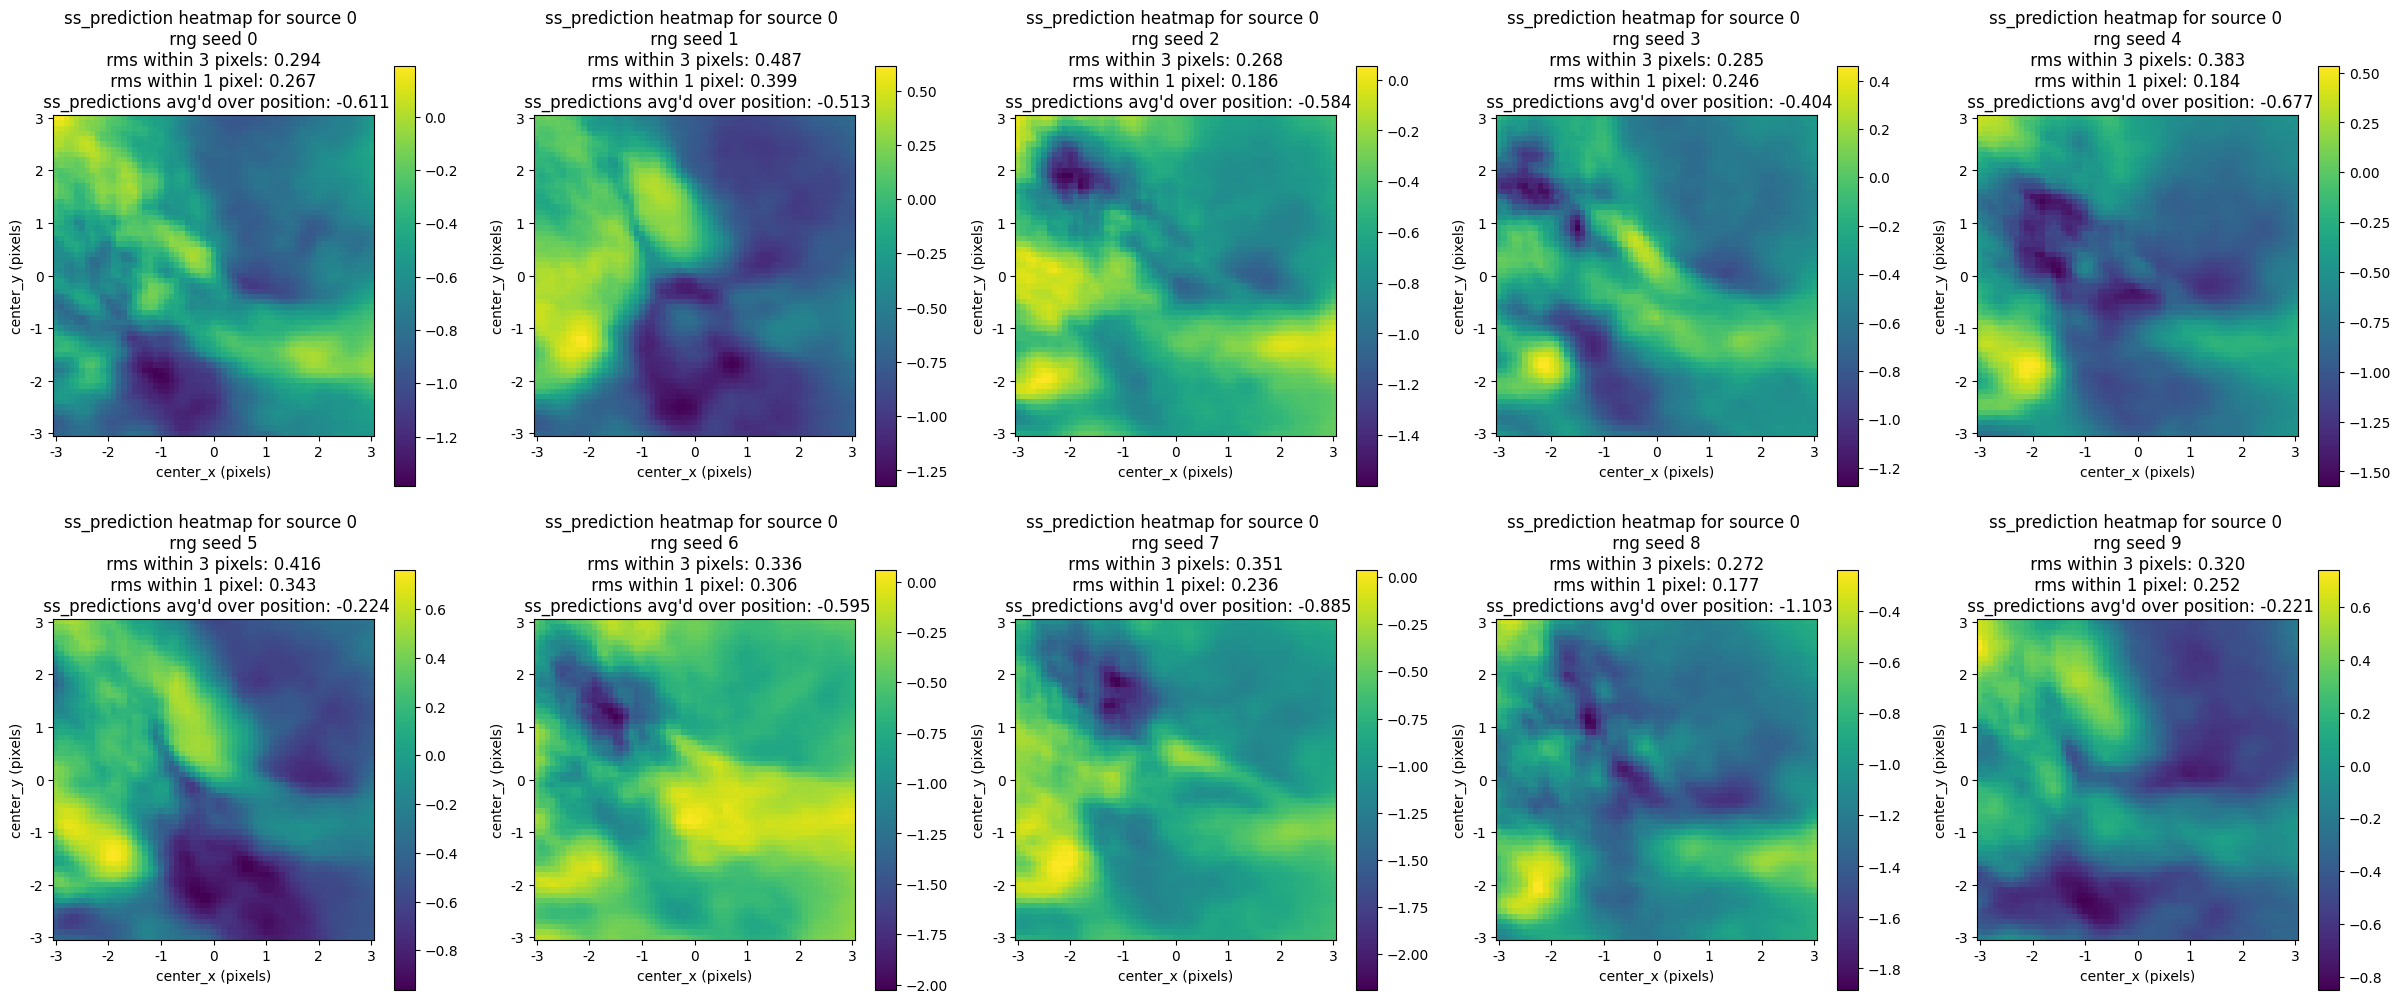

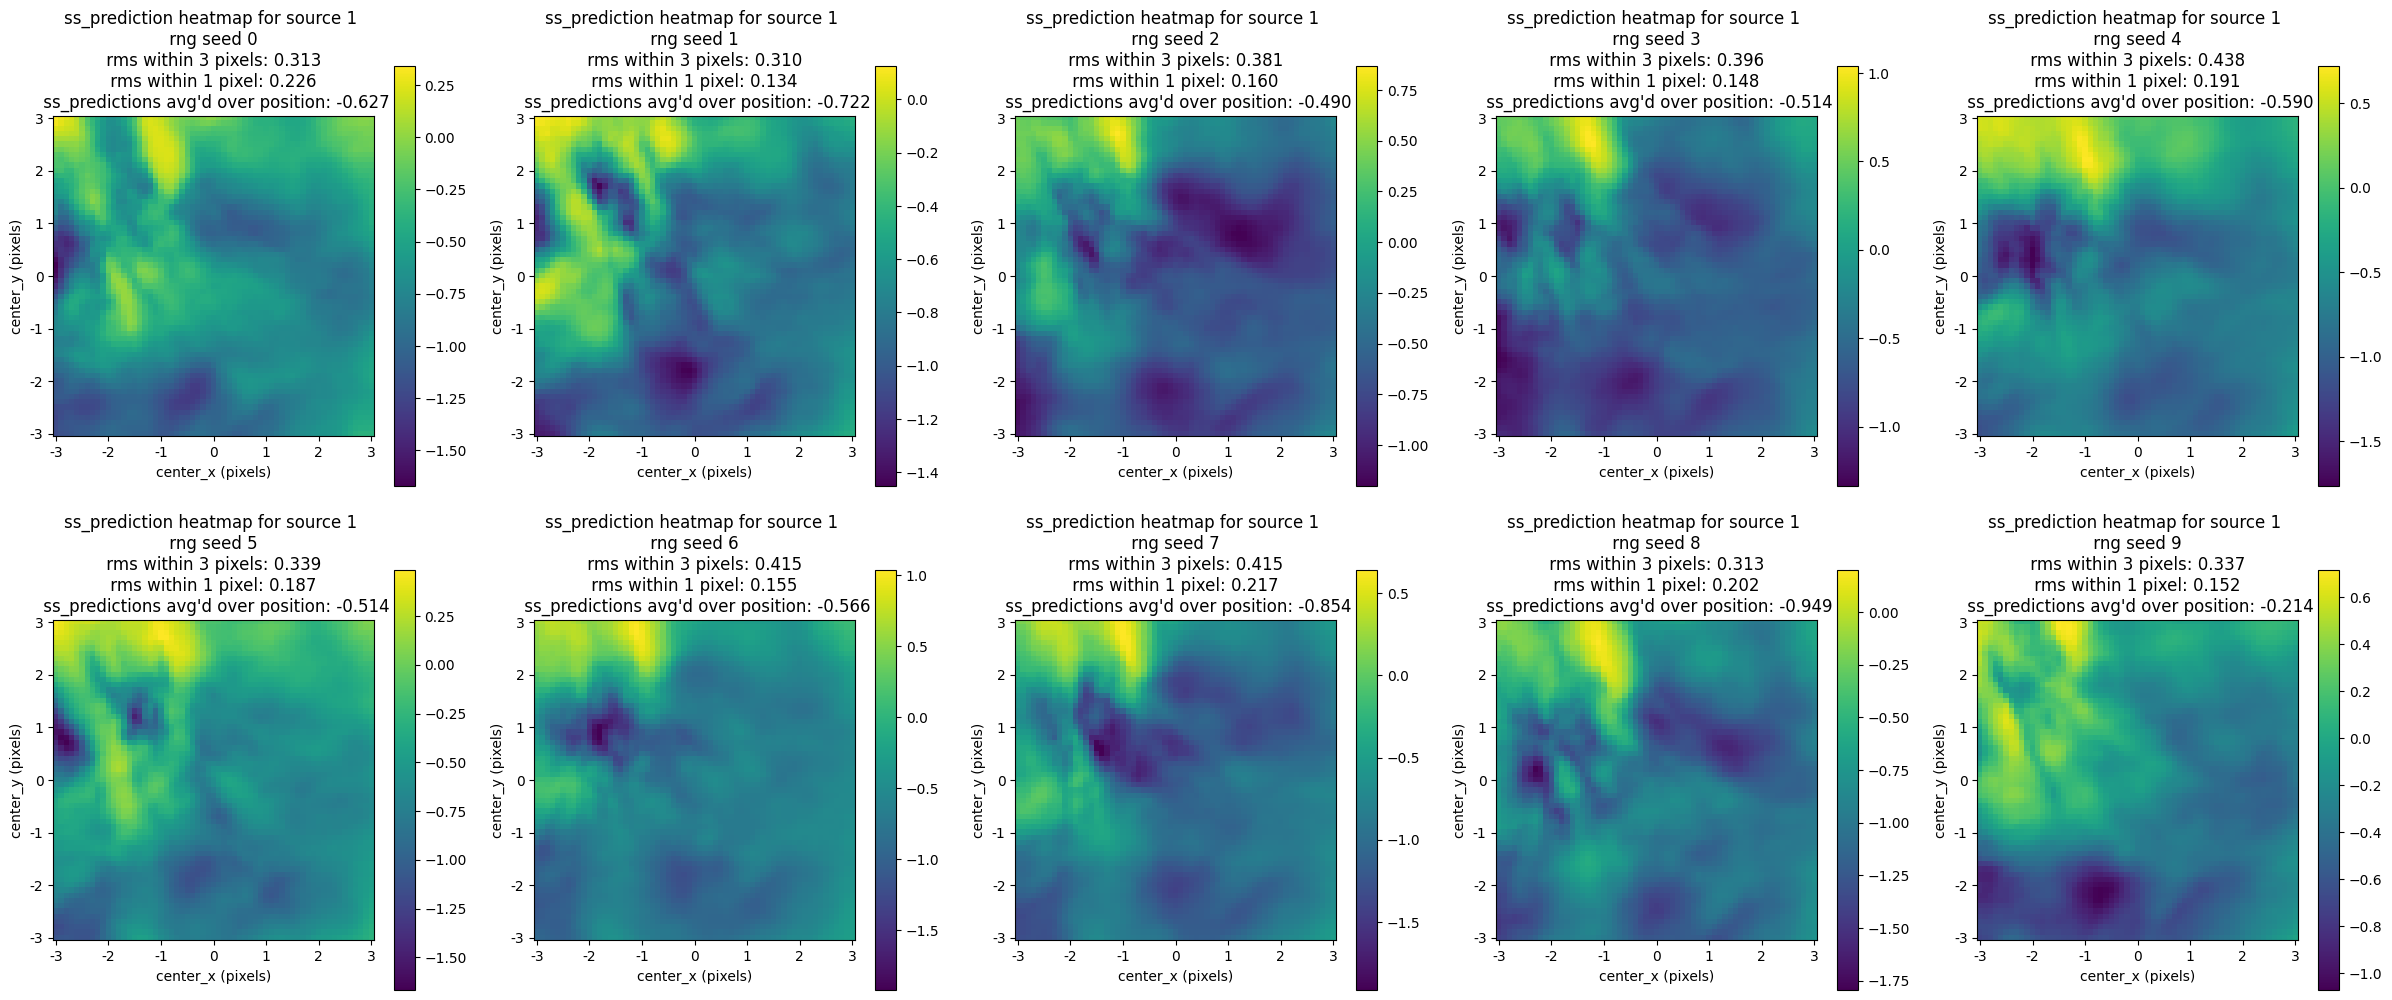

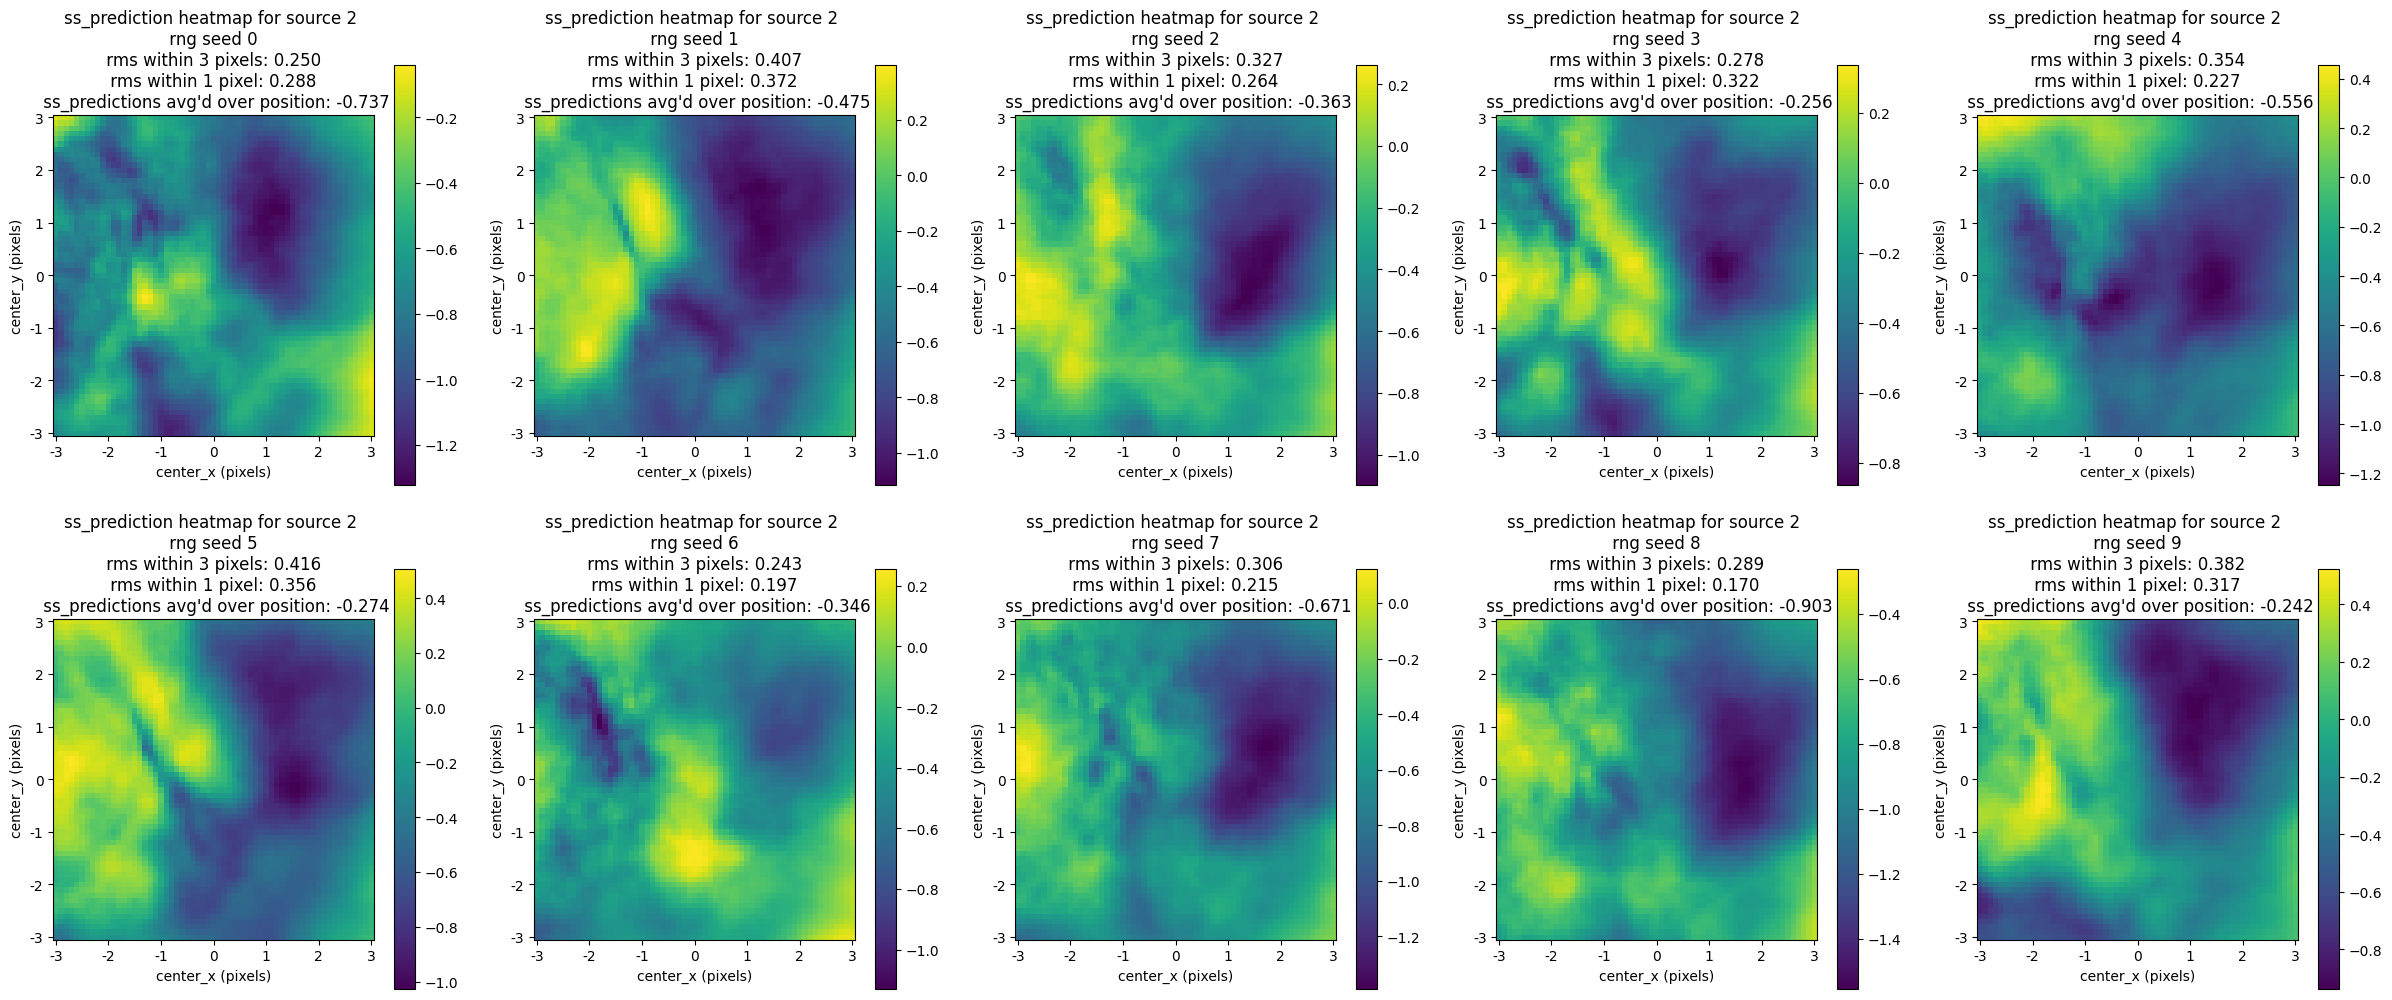

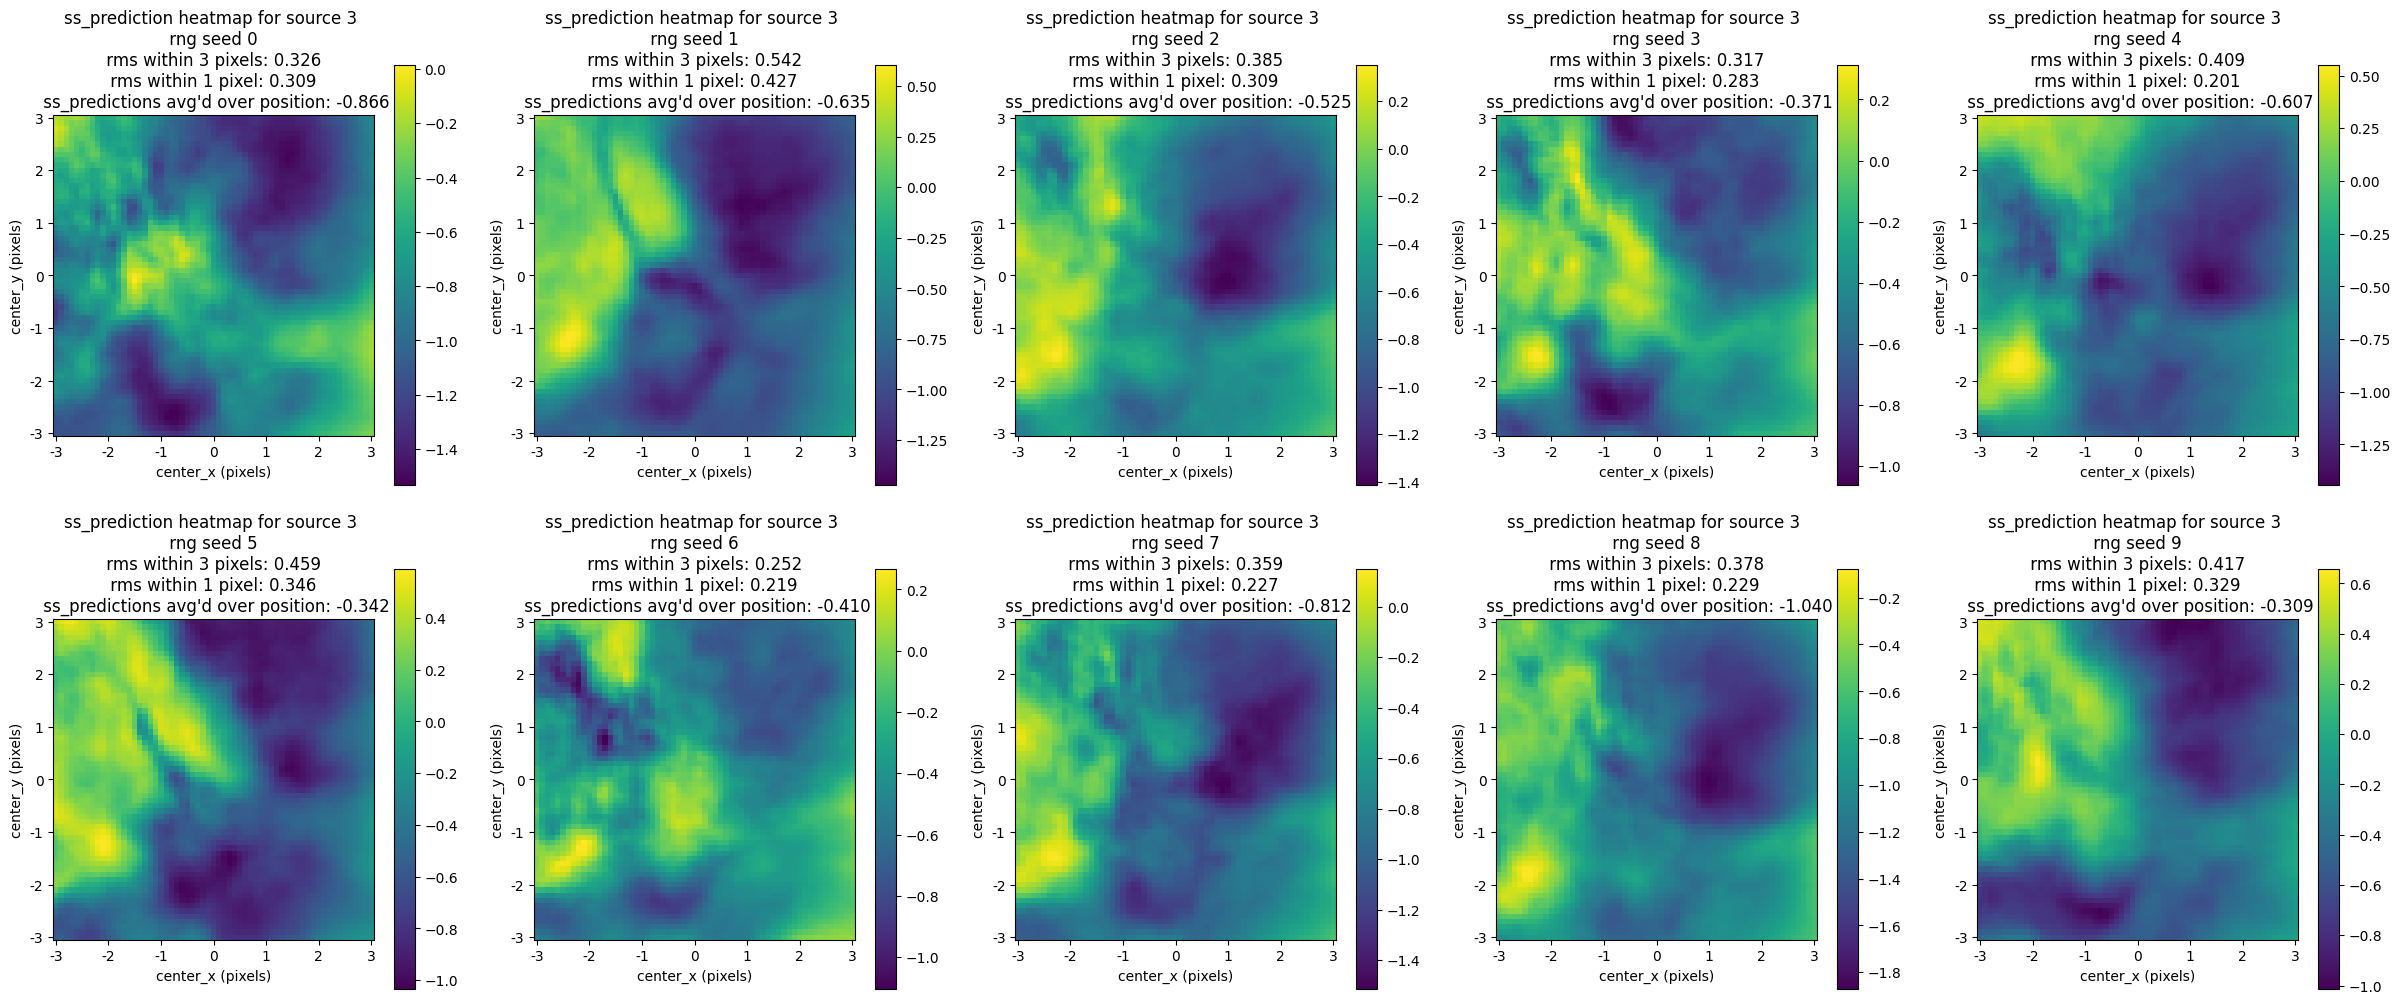

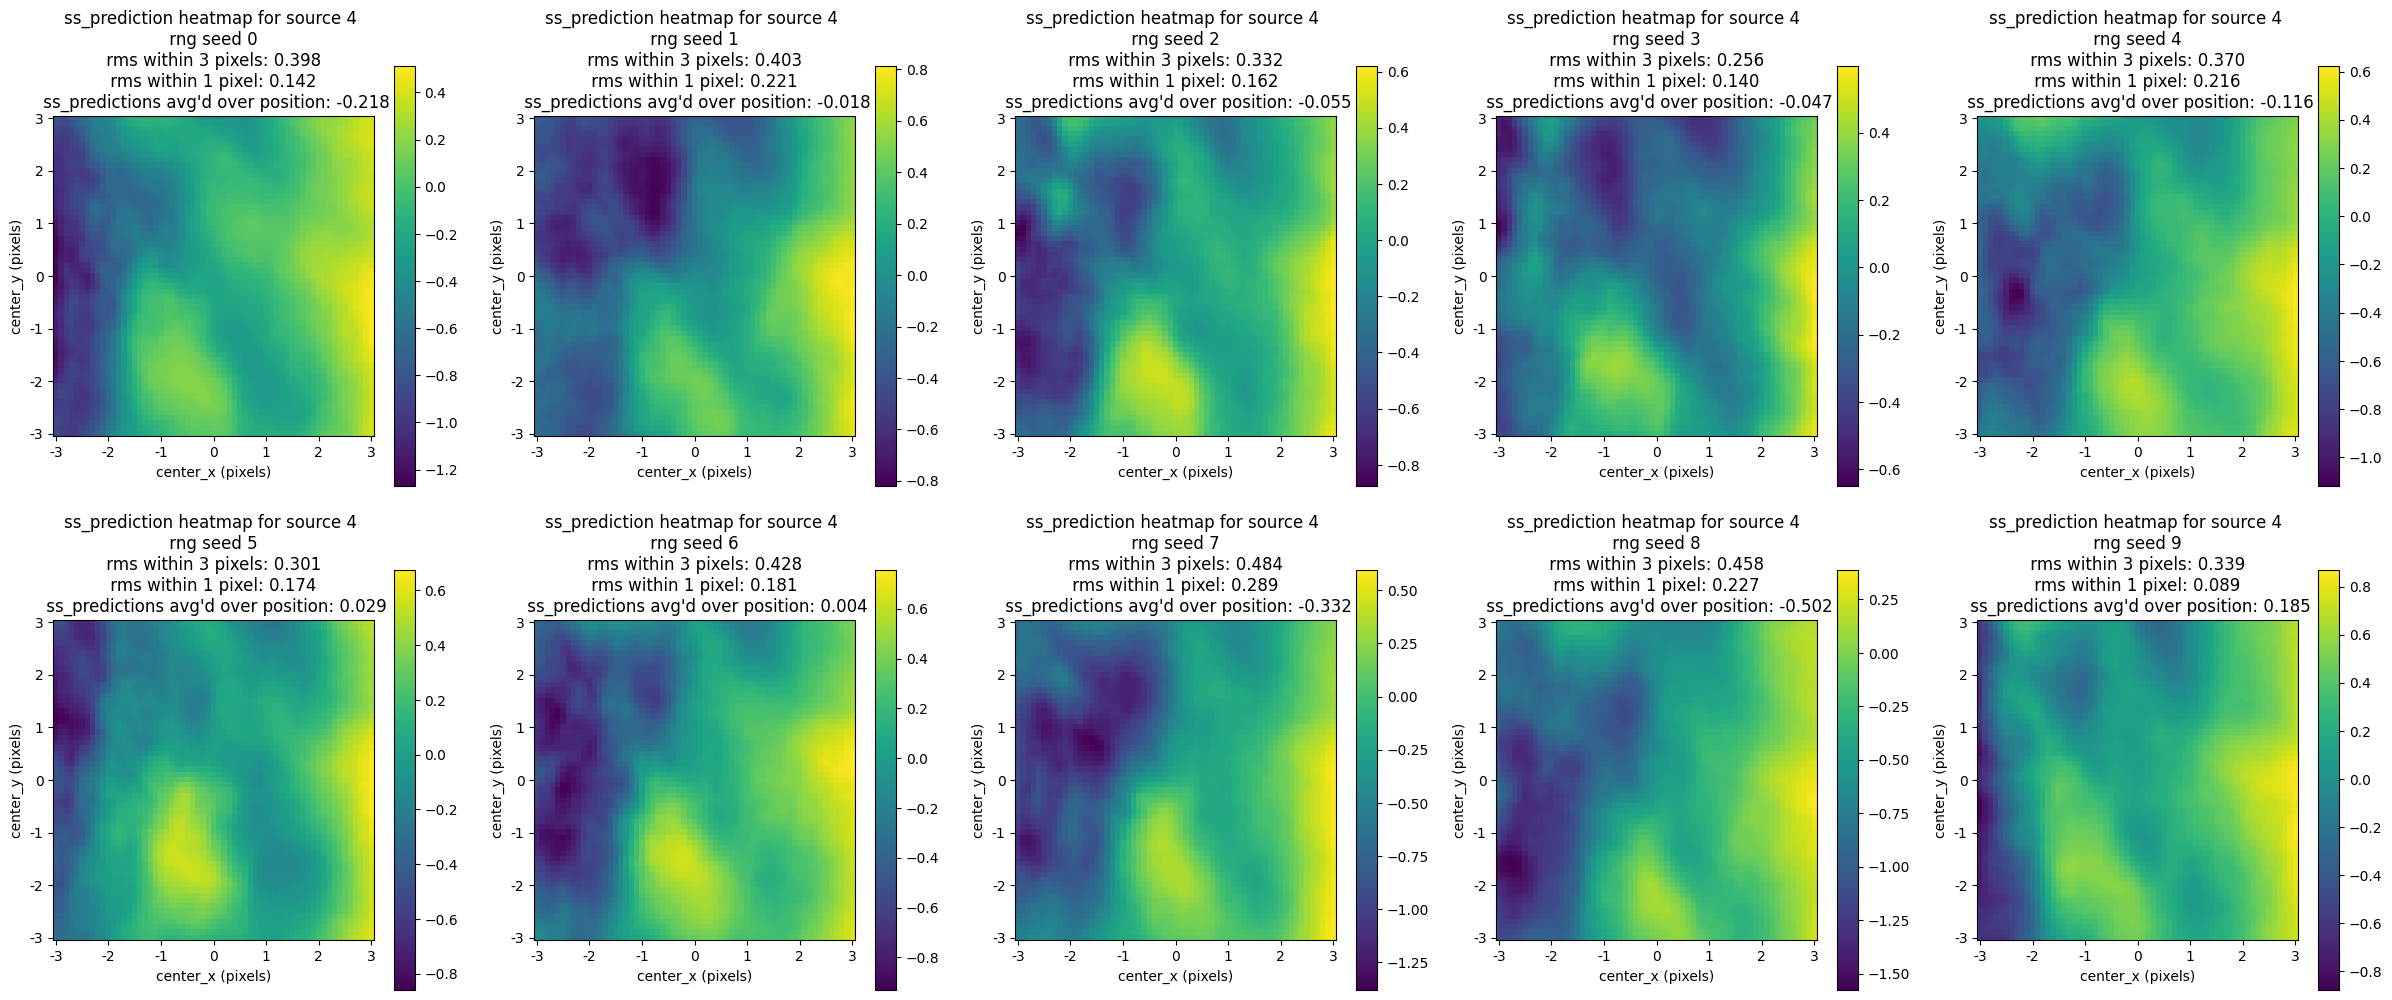

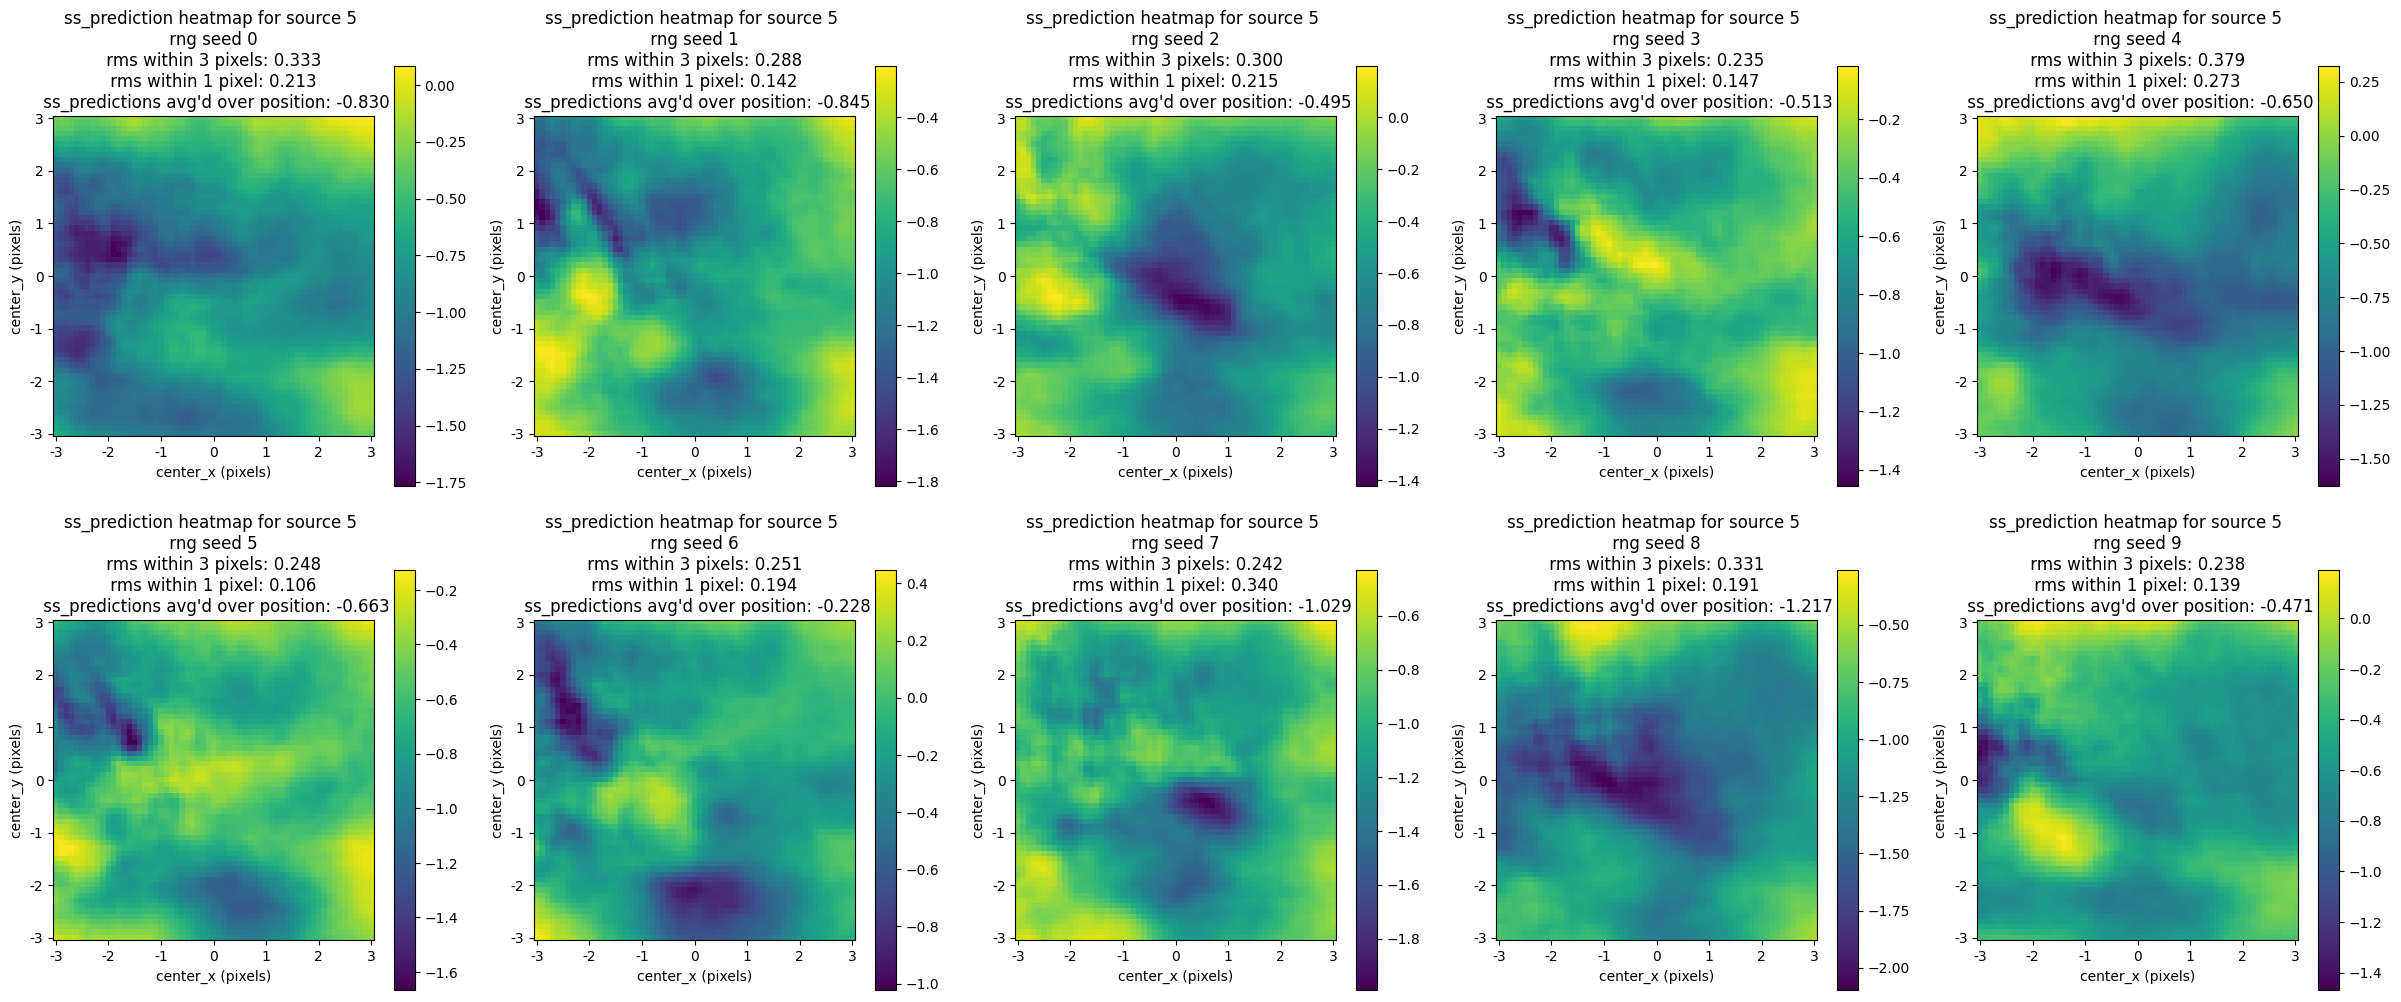

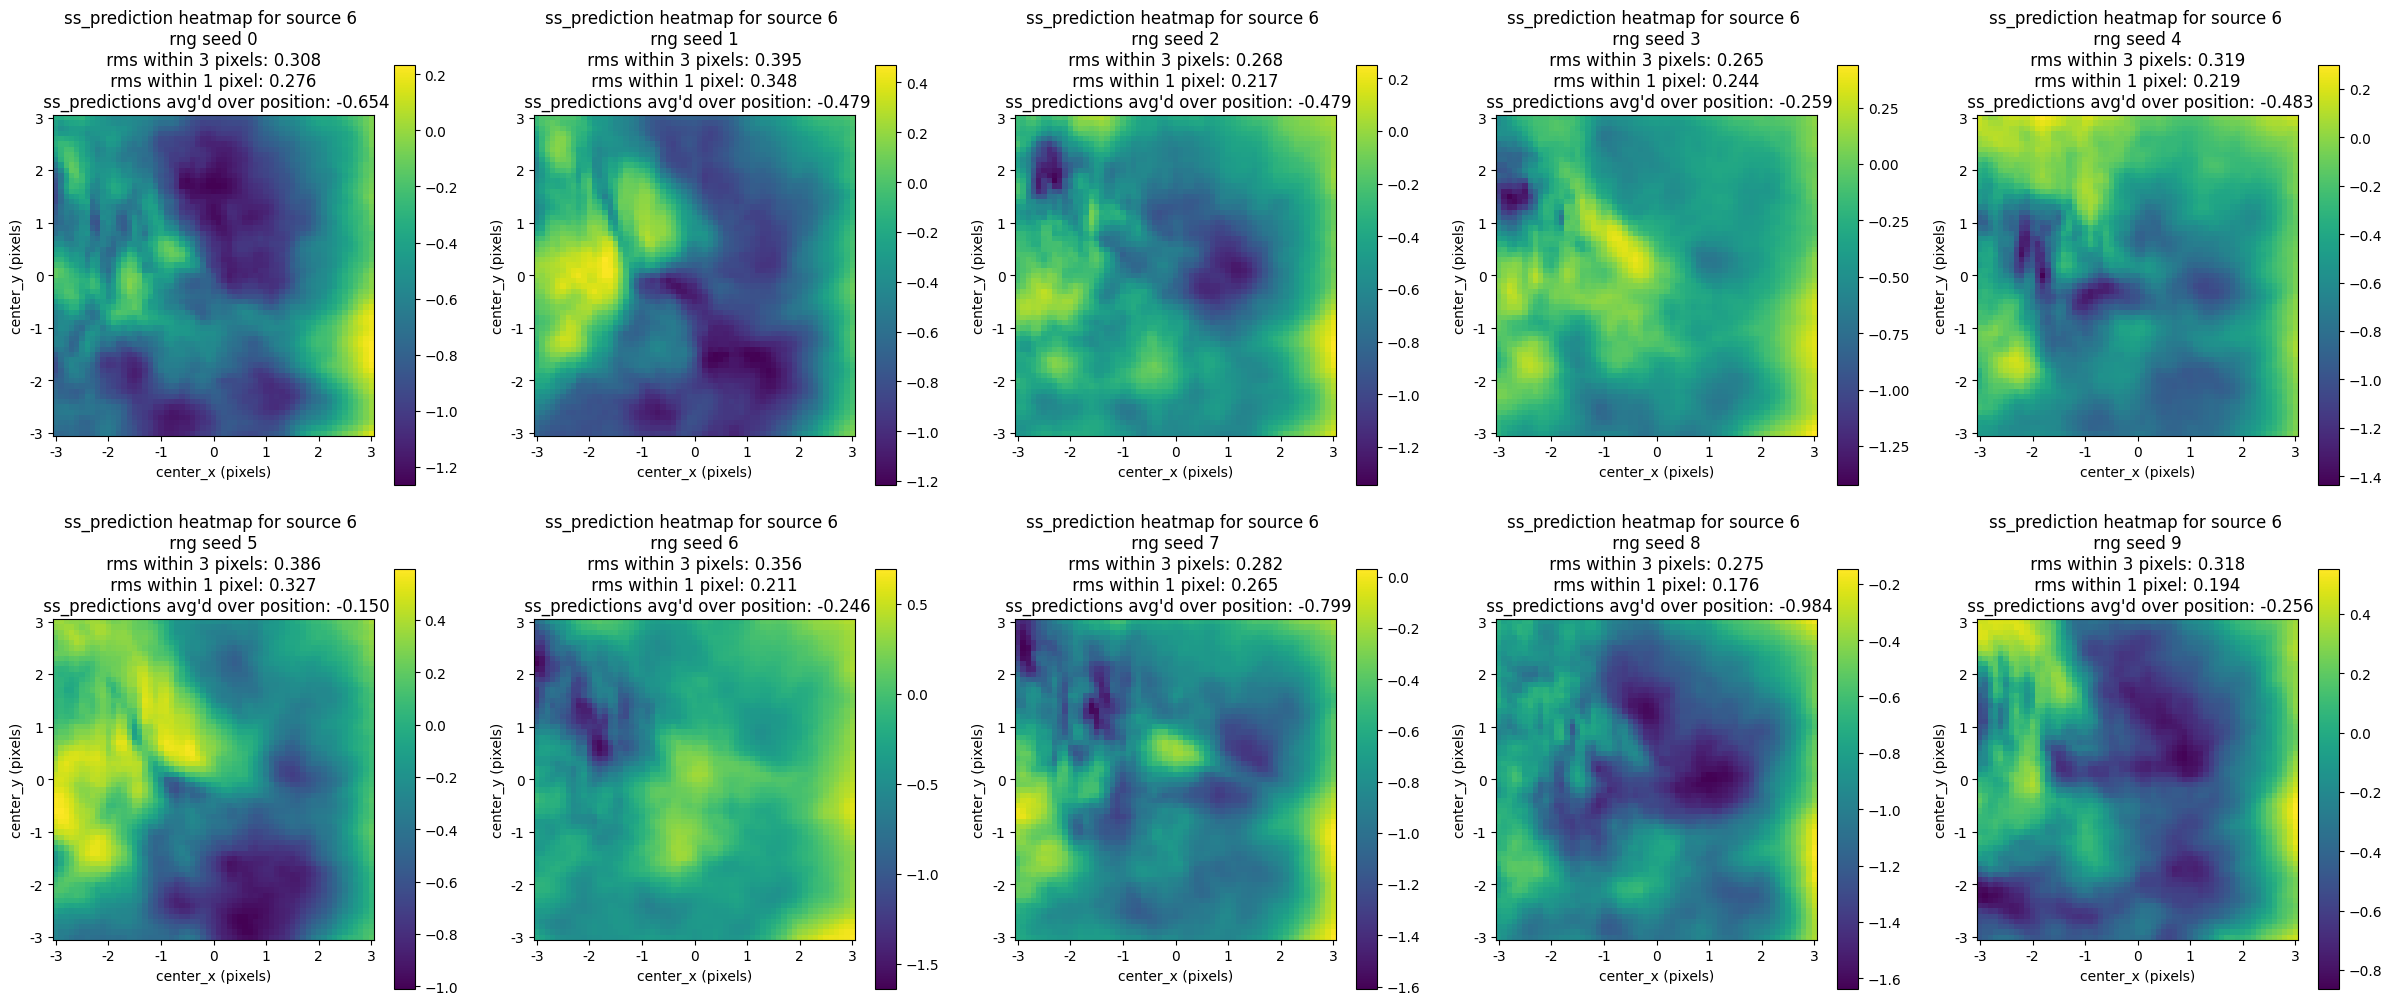

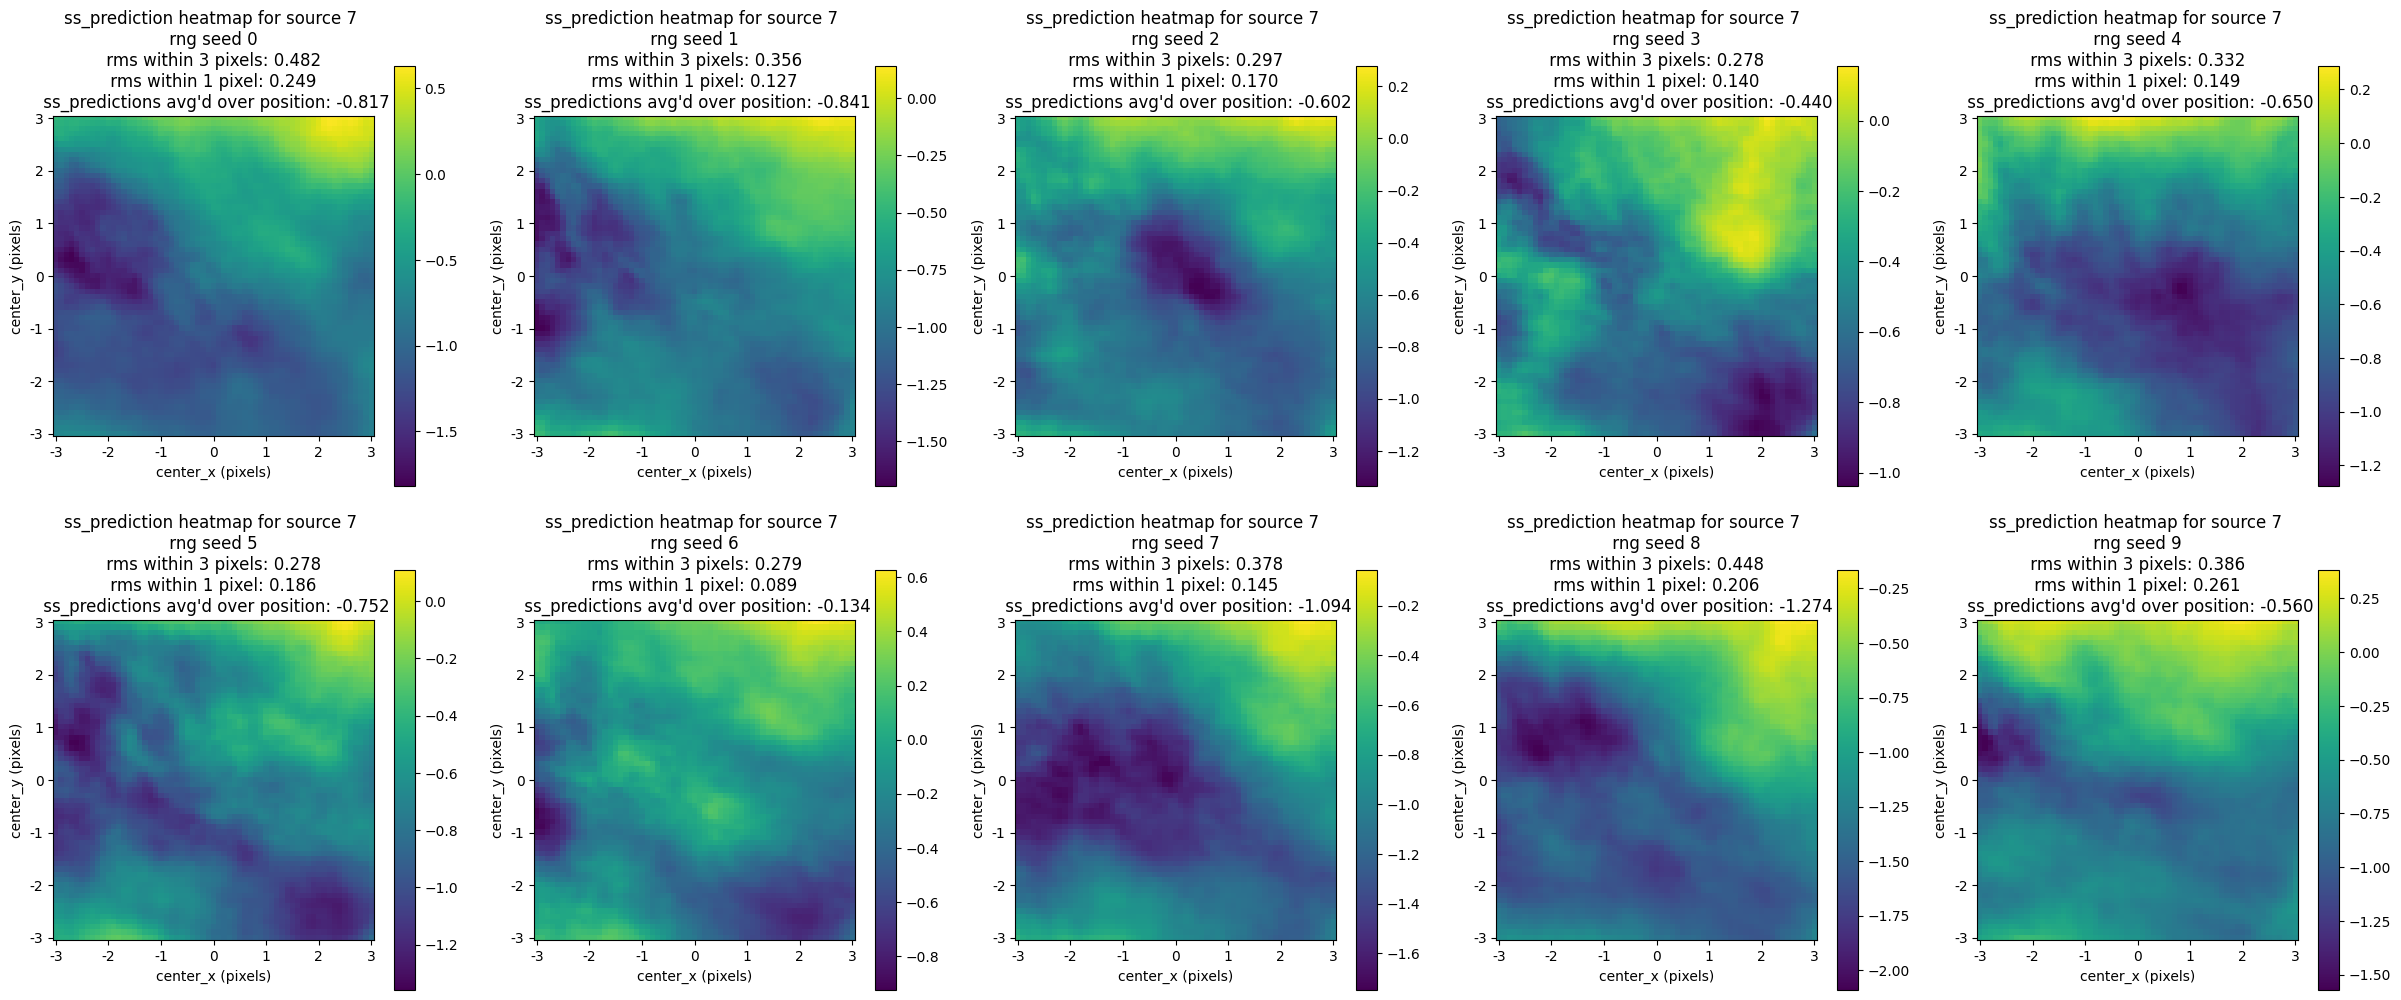

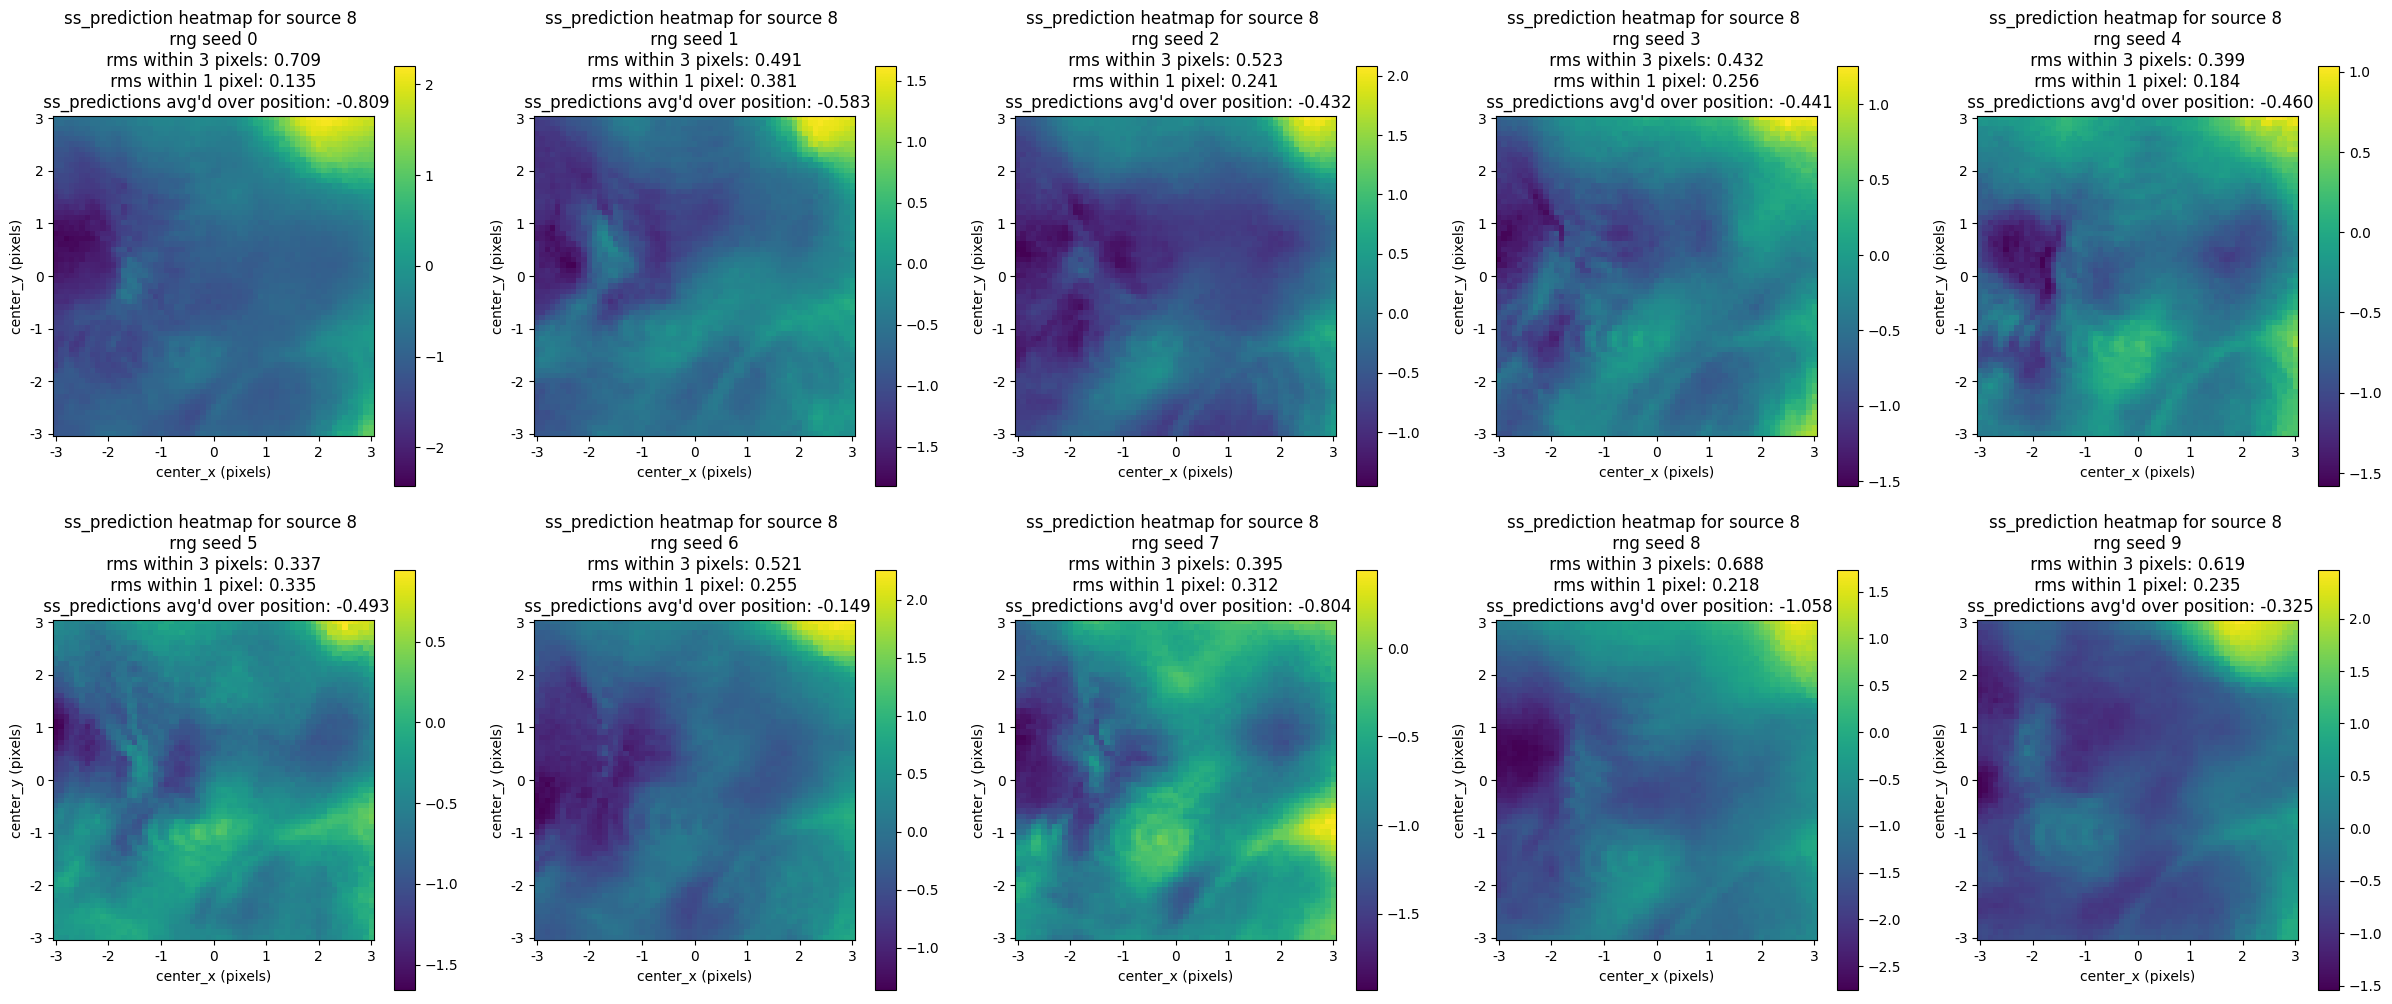

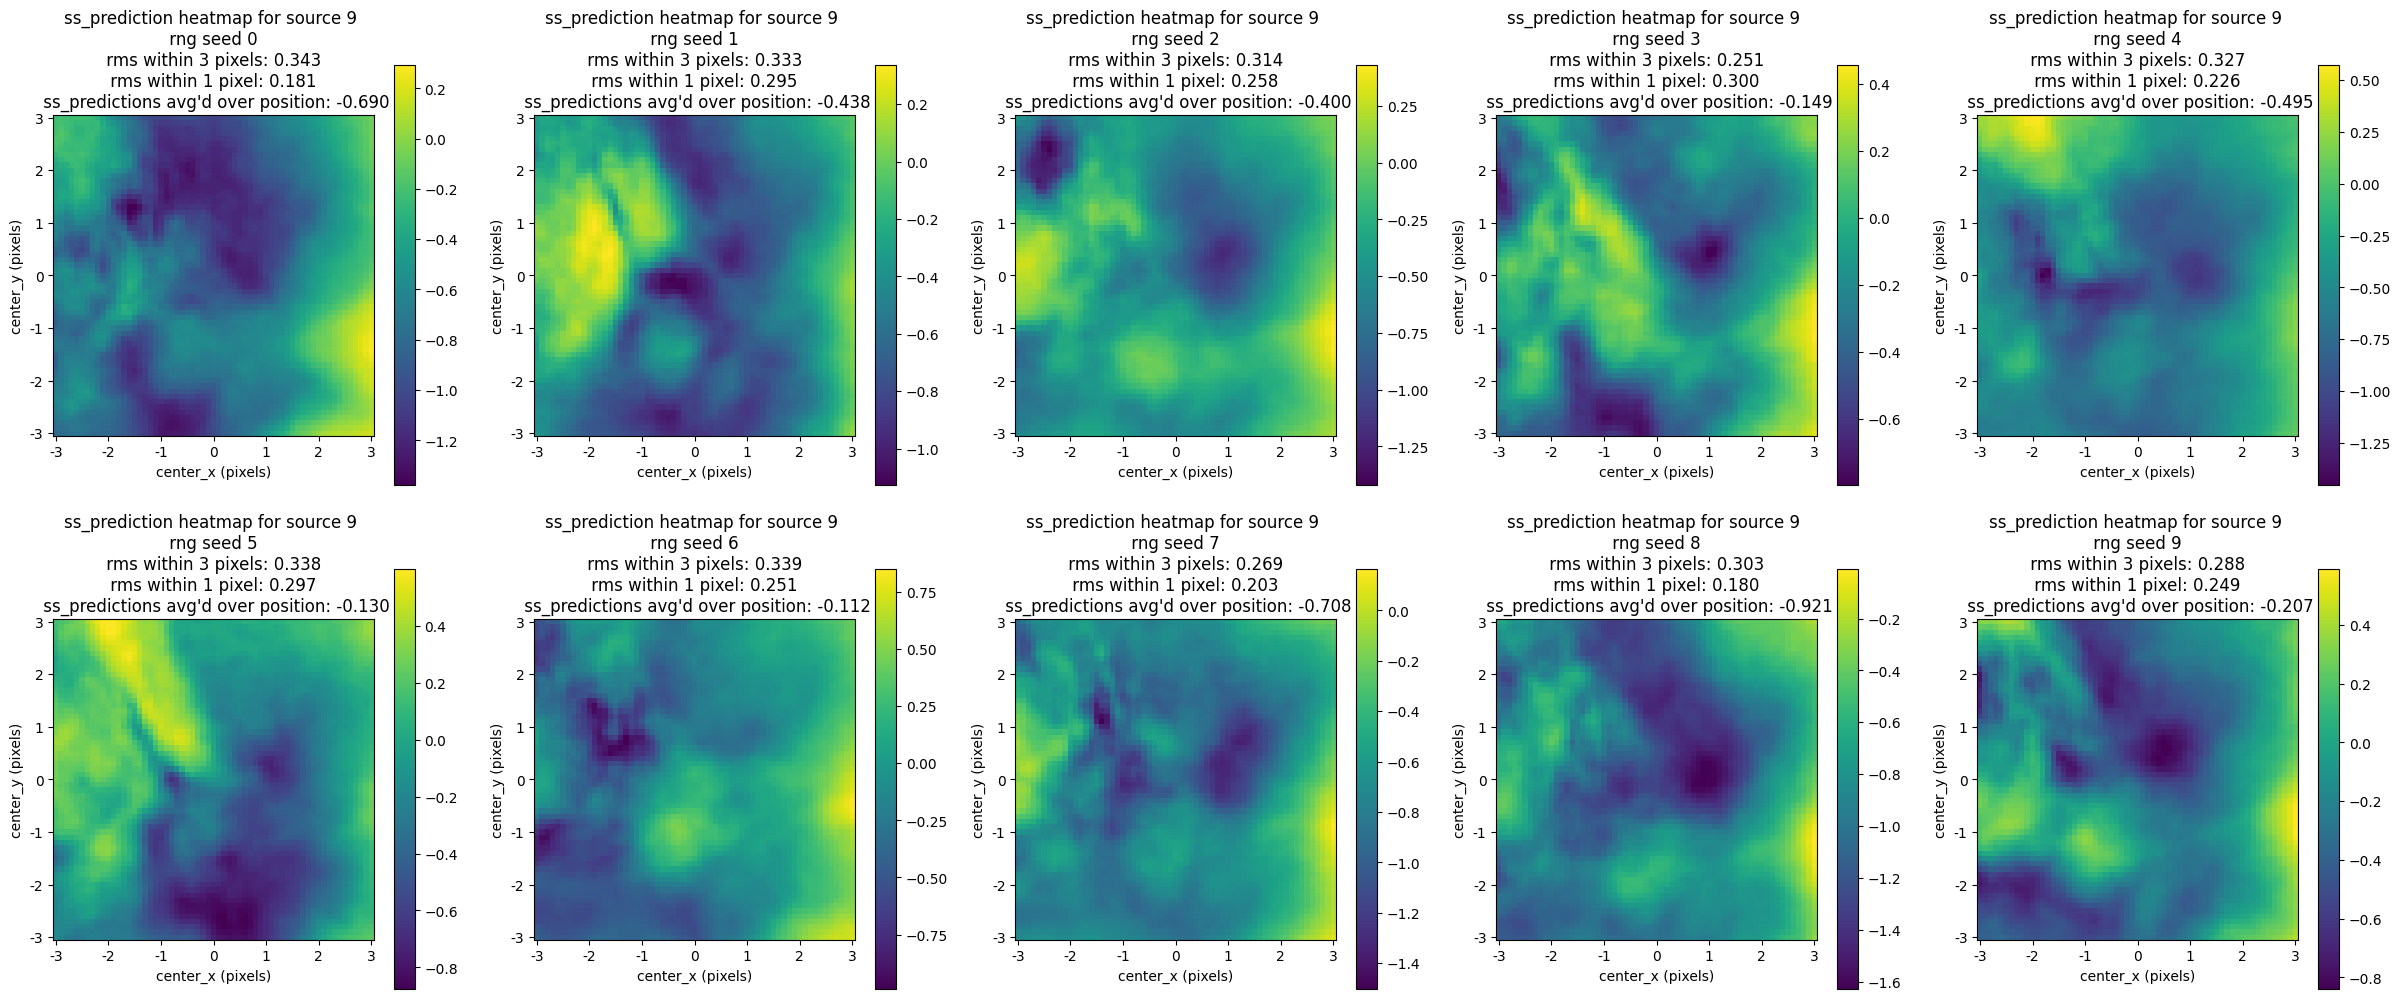

In [ ]:
import matplotlib.pyplot as plt

ss_truth = truth_hier[0][-1]

for source_number in range(10):

    with open(home + f'/heat_maps_source{source_number}.npy', 'rb') as file:
        heat_maps_one_source = np.load(file)

    rms3 = []
    rms1 = []
    avg_ss = []
    fig, ax = plt.subplots(2, 5)
    
    for i in range(10):

        current_fig = ax[int(i / 5)][i % 5]
        im = current_fig.imshow(heat_maps_one_source[i])
        rms3.append('{0:.3f}'.format(rms_spread((heat_maps_one_source[i]).reshape(-1))))
        rms1.append('{0:.3f}'.format(rms_spread((heat_maps_one_source[i])[20:40, 20:40].reshape(-1))))
        avg_ss.append('{0:.3f}'.format(np.average(heat_maps_one_source[i])))
        current_fig.set_title(f"ss_prediction heatmap for source {source_number} \n rng seed {i} \n rms within 3 pixels: {rms3[i]} \n rms within 1 pixel: {rms1[i]} \n ss_predictions avg'd over position: {avg_ss[i]}")
        current_fig.set_xticks([0, 10, 20, 30, 40, 50, 60], [-3, -2, -1, 0, 1, 2, 3])
        current_fig.set_xlabel('center_x (pixels)')
        current_fig.set_yticks([0, 10, 20, 30, 40, 50, 60], [3, 2, 1, 0, -1, -2, -3])
        current_fig.set_ylabel('center_y (pixels)')
        plt.colorbar(im, ax=current_fig)
    fig.set_figwidth(30)
    fig.set_figheight(12)
    plt.show()

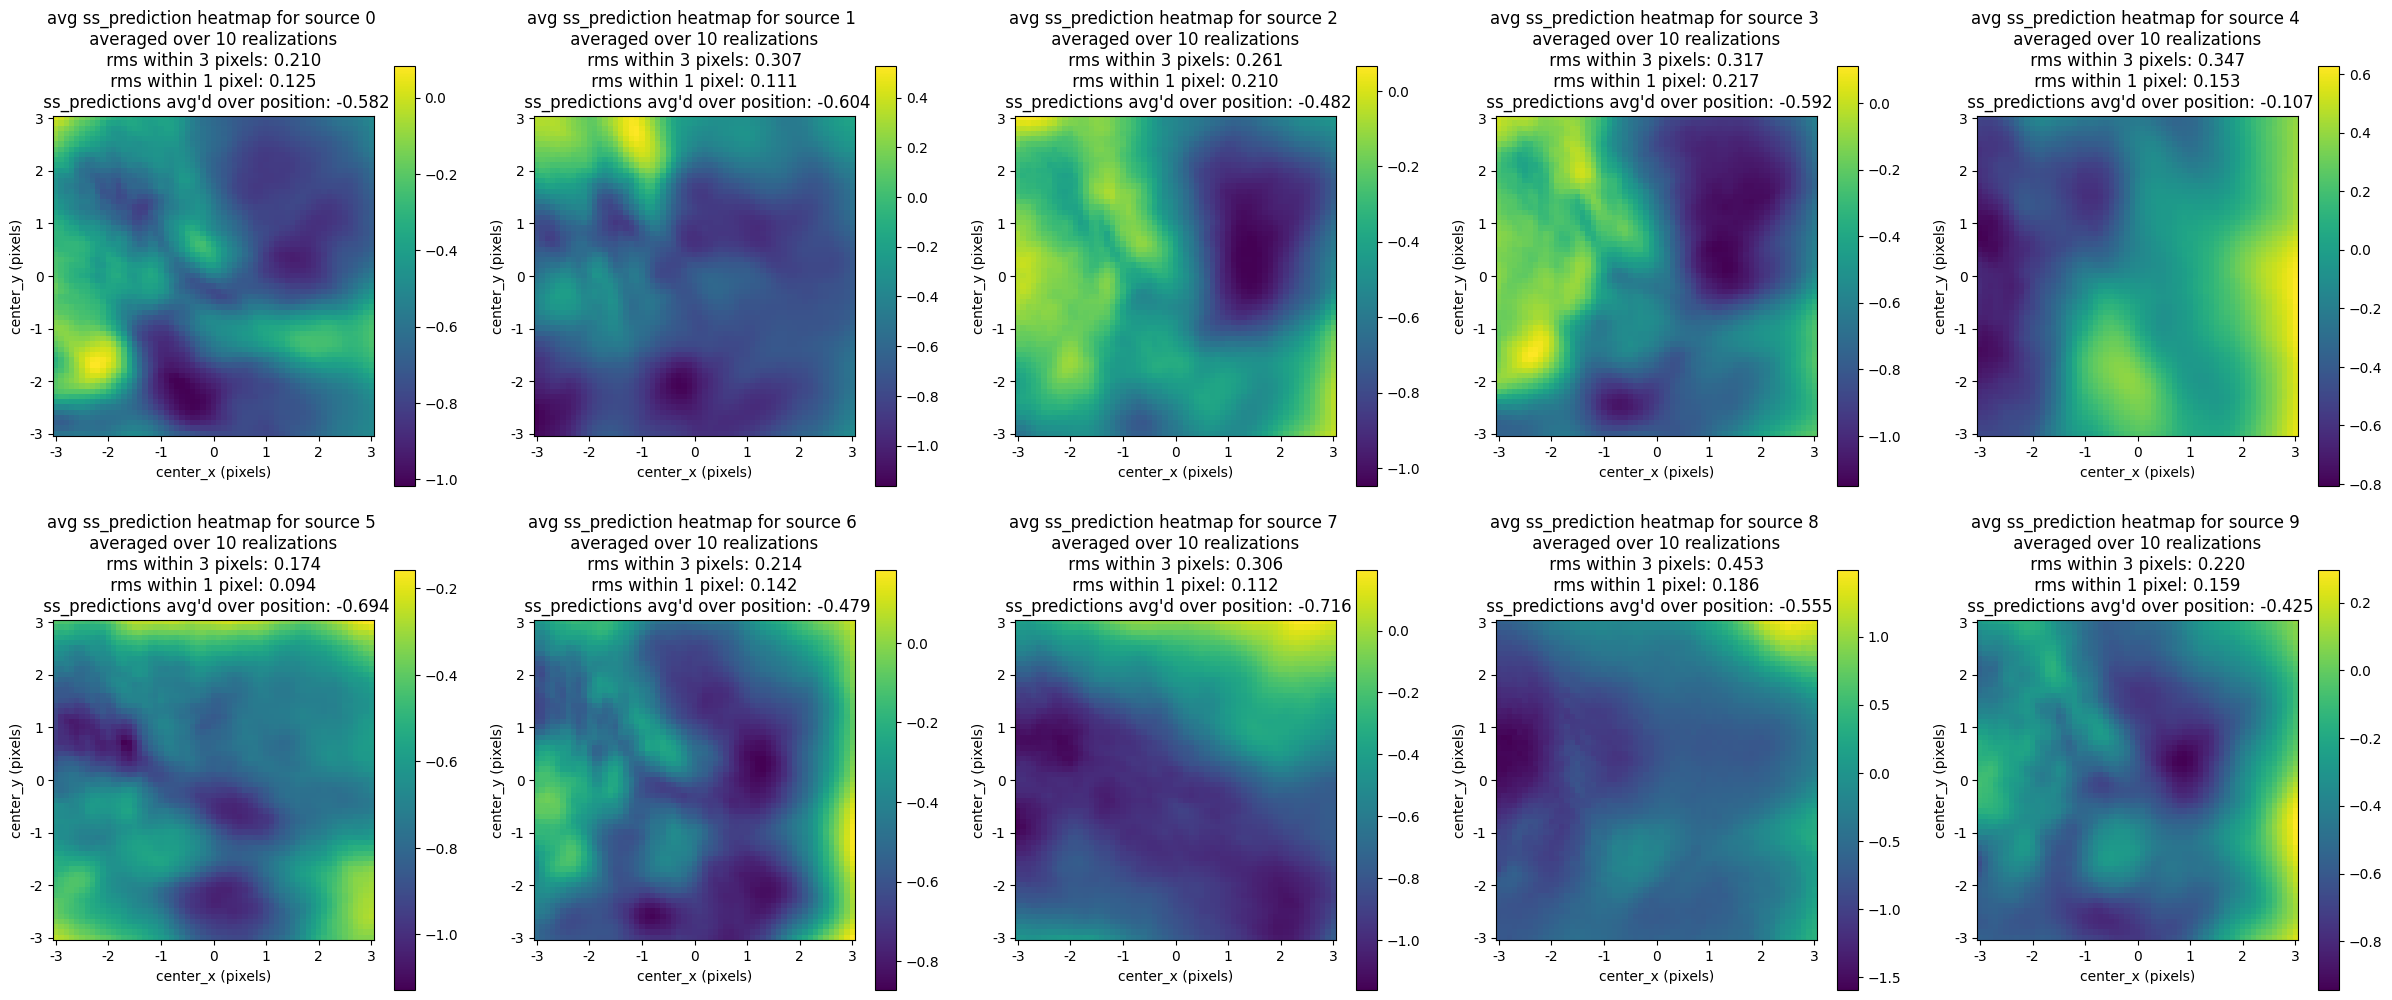

In [67]:
avg_heat_maps = []

for source_number in range(10):
    with open(home + f'/heat_maps_source{source_number}.npy', 'rb') as file:
        heat_maps_one_source = np.load(file)
        avg_heat_maps.append(np.average(heat_maps_one_source, axis=0))

avg_heat_maps = np.array(avg_heat_maps)

#---------------------------------------------------------------------------------

import matplotlib.pyplot as plt

ss_truth = truth_hier[0][-1]

fig, ax = plt.subplots(2, 5)

rms3 = []
rms1 = []
avg_ss = []

for i in range(10):

    current_fig = ax[int(i / 5)][i % 5]
    im = current_fig.imshow(avg_heat_maps[i])
    rms3.append('{0:.3f}'.format(rms_spread((avg_heat_maps[i]).reshape(-1))))
    rms1.append('{0:.3f}'.format(rms_spread((avg_heat_maps[i])[20:40, 20:40].reshape(-1))))
    avg_ss.append('{0:.3f}'.format(np.average(avg_heat_maps[i])))
    current_fig.set_title(f"avg ss_prediction heatmap for source {i} \n averaged over 10 realizations \n rms within 3 pixels: {rms3[i]} \n rms within 1 pixel: {rms1[i]} \n ss_predictions avg'd over position: {avg_ss[i]}")
    current_fig.set_xticks([0, 10, 20, 30, 40, 50, 60], [-3, -2, -1, 0, 1, 2, 3])
    current_fig.set_xlabel('center_x (pixels)')
    current_fig.set_yticks([0, 10, 20, 30, 40, 50, 60], [3, 2, 1, 0, -1, -2, -3])
    current_fig.set_ylabel('center_y (pixels)')
    plt.colorbar(im, ax=current_fig)
fig.set_figwidth(30)
fig.set_figheight(12)
plt.show()

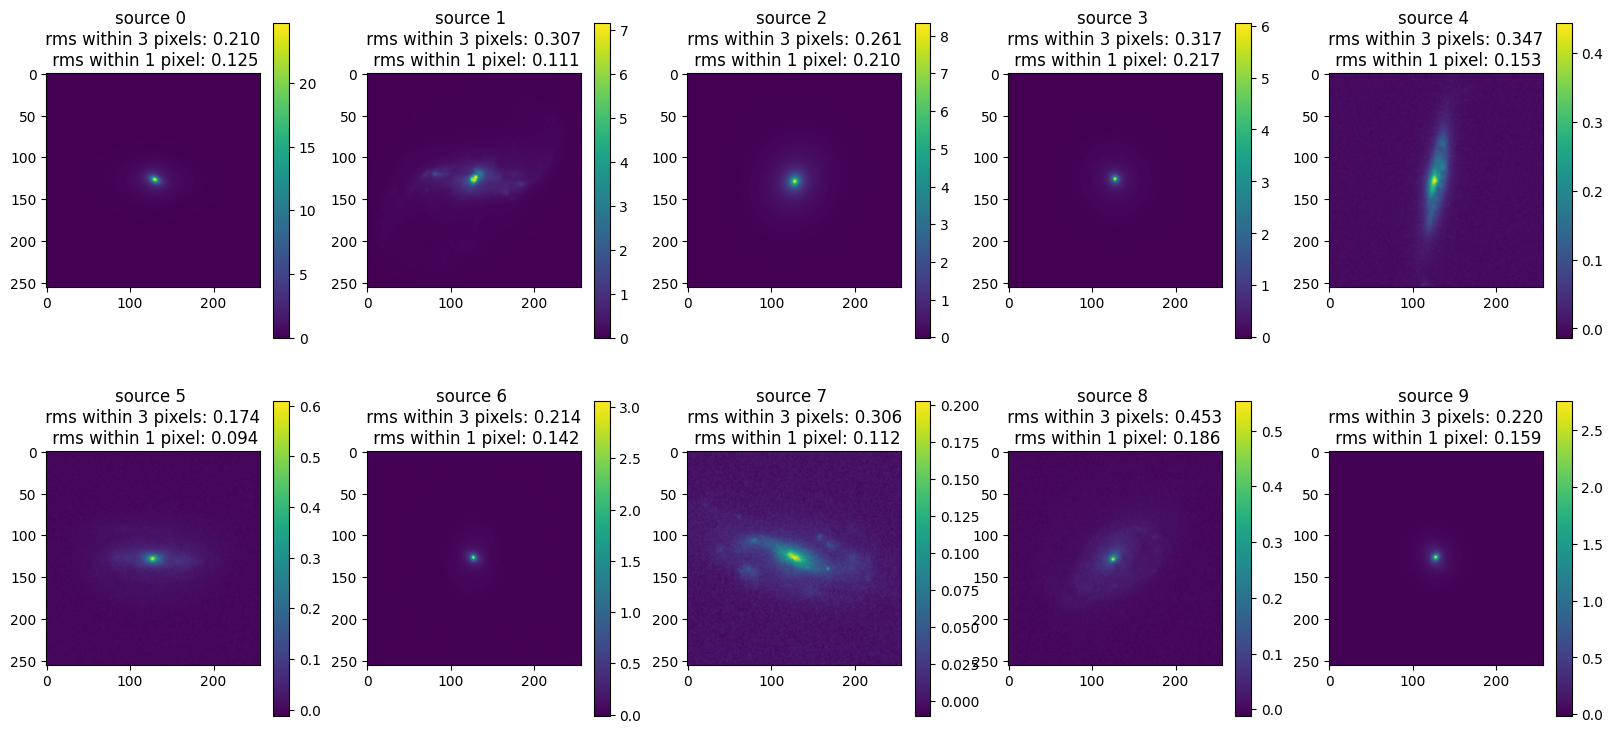

In [71]:
import h5py

galaxy_image_list = []

with h5py.File(home + r'/weighted_catalog_training.h5', 'r') as file:
    galaxy_image_list.append(file['images'][:])


import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 5)
for i in range(10):
    im_i = ax[int(i/5)][i%5].imshow(galaxy_image_list[0][i])
    ax[int(i/5)][i%5].set_title(f"source {i} \n rms within 3 pixels: {rms3[i]} \n rms within 1 pixel: {rms1[i]}")
    plt.colorbar(im_i, ax=ax[int(i/5)][i%5])
fig.set_figheight(9)
fig.set_figwidth(20)
plt.show()

## Testing how the model performs on images interpolated between two sources

First we create the interpolated images

In [19]:
import h5py
import numpy as np
import os
home = os.environ['HOME']
import numpy as np

redshift_list = []
galaxy_image_list = []

galaxies_to_interpolate = (69, 81)
g0 = galaxies_to_interpolate[0]
g1 = galaxies_to_interpolate[1]
num_interpolations = 10

with h5py.File(home + r'/weighted_catalog_training.h5', 'r') as file:
    key_list = [key for key in file.keys()]
    redshift_list = file['redshifts'][:]
    galaxy_image_list = file['images'][:]
    with h5py.File(home + f'/weighted_catalog_training_{g0}_{g1}_interpolation_test.h5', 'w') as interpolation_file:
        for key in key_list:
            if key == "images":
                data = np.zeros((num_interpolations+2, 256, 256))
                i = 0
                for t in np.linspace(0., 1., num_interpolations+2):
                    data[i] = file[key][g0] * (1-t) + file[key][g1] * t
                    i += 1
            else:
                data = np.zeros(num_interpolations+2)
                data[:] = file[key][g0]
            interpolation_file.create_dataset(key, data=data)

Here's what these interpolated images look like:

['asymmetry', 'asymmetry_weights', 'axial_ratio', 'axial_ratio_weights', 'concpetro', 'concpetro_weights', 'gini', 'gini_weights', 'images', 'm20', 'm20_weights', 'pixel_sizes', 'redshifts', 'rhalfreal', 'rhalfreal_weights', 'rpetroreal', 'rpetroreal_weights']
[0.07 0.07 0.07 0.07 0.07 0.07 0.07 0.07 0.07 0.07 0.07 0.07]
[0.171 0.171 0.171 0.171 0.171 0.171 0.171 0.171 0.171 0.171 0.171 0.171]


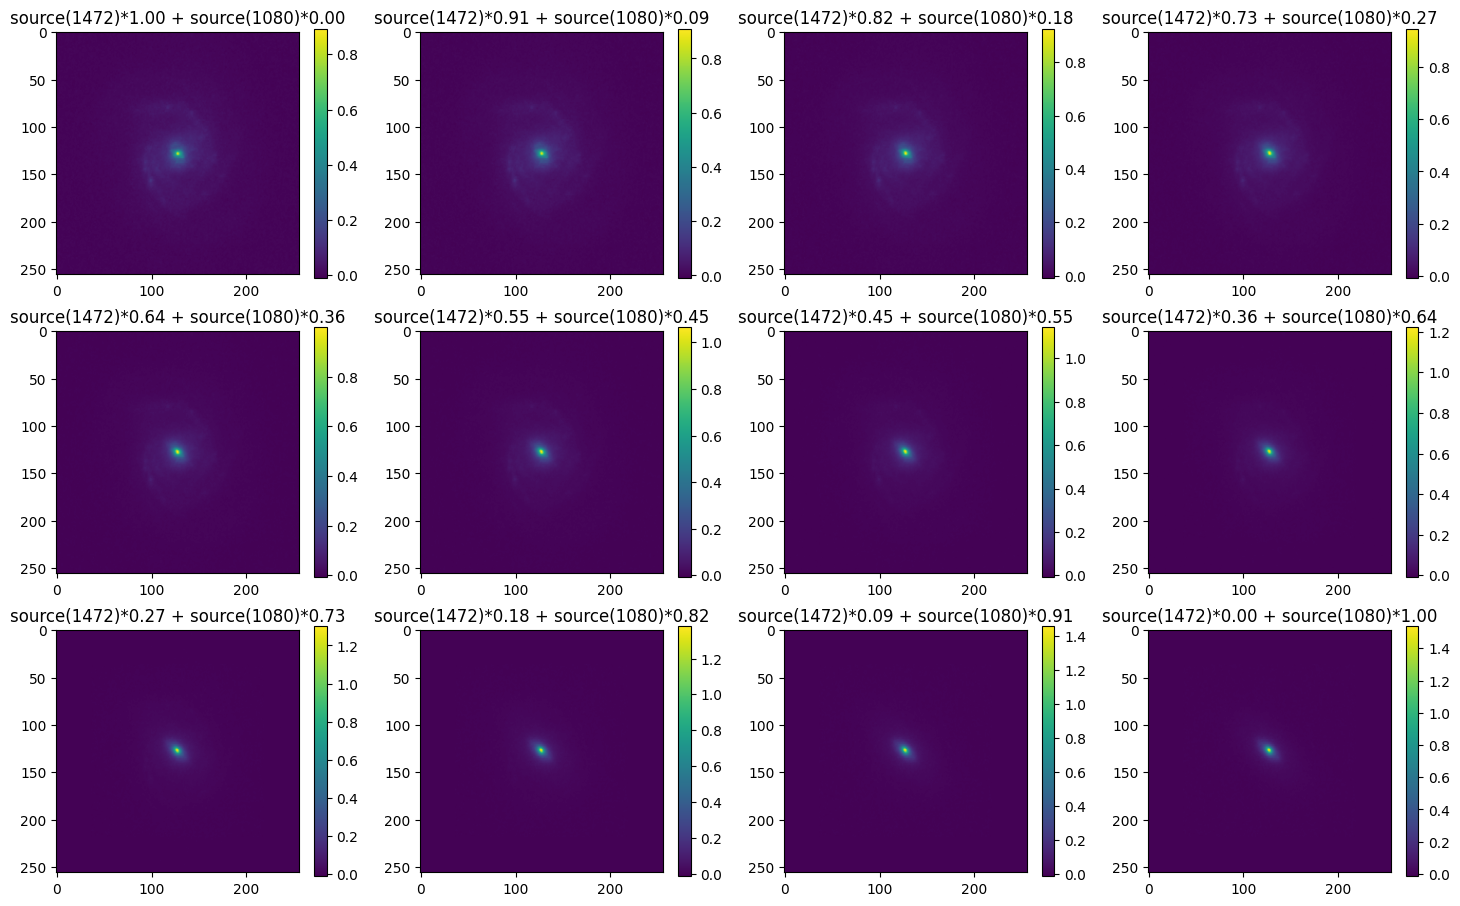

In [30]:
galaxies_to_interpolate = (1472, 1080)
g0 = galaxies_to_interpolate[0]
g1 = galaxies_to_interpolate[1]

interpolated_images = []

with h5py.File(home + f'/weighted_catalog_training_{g0}_{g1}_interpolation.h5', 'r') as file:
    key_list = [key for key in file.keys()]
    print(key_list)
    print(file['redshifts'][:])
    print(file['asymmetry'][:])
    interpolated_images = file['images'][:]

fig, ax = plt.subplots(3,4)
t = np.linspace(0., 1., num_interpolations+2)
for i in range(12):
    ax[int(i / 4)][i % 4].set_title(f"source({g0})*{'{0:.2f}'.format(1-t[i])} + source({g1})*{'{0:.2f}'.format(t[i])}")
    im_i = ax[int(i / 4)][i % 4].imshow(interpolated_images[i])
    plt.colorbar(im_i, ax=ax[int(i / 4)][i % 4])
fig.set_figwidth(18)
fig.set_figheight(11)
plt.show()

Now run the model on these images:

In [14]:
sources_interpolated = (69, 81)
g0 = sources_interpolated[0]
g1 = sources_interpolated[1]

cosmos_path = home + f'/weighted_catalog_training_{g0}_{g1}_interpolation.h5'
input_config_test = train._get_config(config.input_config_path)
input_config_test['all_models']['all_source_models'] = (source_models.CosmosCatalog(cosmos_path,12),)
assert input_config_test['all_models']['all_source_models'][0].images_per_chunk == 12

draw_image_and_truth_vmap = jax.jit(jax.vmap(
        functools.partial(
            input_pipeline.draw_image_and_truth,
            all_models=input_config_test['all_models'],
            principal_model_indices=input_config_test['principal_model_indices'],
            kwargs_simulation=input_config_test['kwargs_simulation'],
            kwargs_detector=input_config_test['kwargs_detector'],
            kwargs_psf=input_config_test['kwargs_psf'],
            truth_parameters=input_config_test['truth_parameters'],
            normalize_config=input_config_test['lensing_config']),
        in_axes=(None, None, None, None, 0, None)))
cosmology_params = input_pipeline.initialize_cosmology_params(input_config_test, rng)

In [15]:
std_norm = config.std_norm
mean_norm = config.mean_norm

mu_test_unormalized = truth_hier[0] * std_norm + mean_norm
std_test_unormalized = std_norm * 0.01

for truth_i in range(len(input_config_test['truth_parameters'][0])):
    rewrite_object = input_config_test['truth_parameters'][0][truth_i]
    rewrite_key = input_config_test['truth_parameters'][1][truth_i]
    input_config_test['lensing_config'][rewrite_object][rewrite_key] = input_pipeline.encode_constant(
        mu_test_unormalized[truth_i])

galaxy_index_list = []

source_morphology_params_list = {}

# These paramaters change with galaxy index, i.e. they are the same across all realizations for the same source
parameters = ['asymmetry', 'axial_ratio', 'concpetro', 'gini', 'm20', 'rhalfreal', 'rpetroreal', 'redshifts']
# These parameters change across different realizations for the same source
realization_parameters = ['amp', 'angle', 'center_x', 'center_y']

for parameter in parameters + realization_parameters:
    source_morphology_params_list[parameter] = []

ss_avg_list = []
ss_avg_variance_list = []

In [16]:
# Use the same rng seed each time
rng = jax.random.PRNGKey(0)
_rng, _ = jax.random.split(rng)
rng_images = jax.random.split(_rng, 100)

for galaxy_num in range(12):

    input_config_test['lensing_config']['source_params']['galaxy_index'] = input_pipeline.encode_constant(galaxy_num/12.)
    #input_config_test['lensing_config']['source_params']['amp'] = input_pipeline.encode_constant(1.3)
    #input_config_test['lensing_config']['source_params']['amp'] = input_pipeline.encode_uniform(minimum=0.5, maximum=2.0)
    #input_config_test['lensing_config']['source_params']['angle'] = input_pipeline.encode_constant(jnp.pi) 
    #input_config_test['lensing_config']['source_params']['angle'] = input_pipeline.encode_uniform(minimum=0.0, maximum=2 * jnp.pi)
    #input_config_test['lensing_config']['source_params']['center_x'] = input_pipeline.encode_normal(mean=center_x_truth, std=0.05) 
    #input_config_test['lensing_config']['source_params']['center_y'] = input_pipeline.encode_normal(mean=center_y_truth, std=0.05) 


    im, t, source_morphology_params, galaxy_index = draw_image_and_truth_vmap(input_config_test['lensing_config'], cosmology_params, grid_x,
                                             grid_y, rng_images, 0.0)
    
    galaxy_index_list.append(galaxy_index[0].item())

    # These paramaters change with galaxy index, i.e. they're the same across all realizations of the same source
    for parameter in parameters:
        source_morphology_params_list[parameter].append(source_morphology_params[parameter][0].item())
        
    # These parameters change across realizations of the same source
    for parameter in realization_parameters:
        source_morphology_params_list[parameter].append(source_morphology_params[parameter][0].reshape(-1))
    
    outputs_hr = get_outputs(state, im)
    mean_hr, log_var_hr = jnp.split(outputs_hr, 2, axis=-1)

    ss_predictions = mean_hr[:, [10]].reshape(-1)

    ss_log_variances = log_var_hr[:, [10]].reshape(-1)
    ss_variances = np.exp(ss_log_variances)

    # calculate the average sigma sub using inverse variance weighted average
    ss_avg_variance = 1./np.sum(1./ss_variances)
    ss_avg = np.sum(ss_predictions/ss_variances) * ss_avg_variance

    ss_avg_list.append(ss_avg)
    ss_avg_variance_list.append(ss_avg_variance)

ss_avg_list = np.array(ss_avg_list)
ss_avg_variance_list = np.array(ss_avg_variance_list)
with open(home + f'/ss_avg_list_sequential_40epochs_{g0}_{g1}_interpolation.npy', 'wb') as file:
    np.save(file, ss_avg_list)
    
with open(home + f'/ss_avg_variance_list_sequential_40epochs_{g0}_{g1}_interpolation.npy', 'wb') as file:
    np.save(file, ss_avg_variance_list)

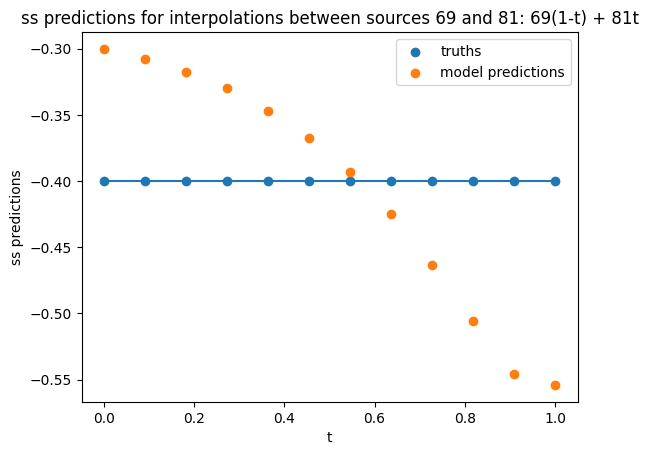

In [18]:
with open(home + f'/ss_avg_list_sequential_40epochs_{g0}_{g1}_interpolation.npy', 'rb') as file:
    ss_avg_list = np.load(file)


import matplotlib.pyplot as plt

x = np.linspace(0., 1., len(ss_avg_list))
y_truth = np.ones_like(x) * truth_hier[0][-1]
y = ss_avg_list

plt.title(f"ss predictions for interpolations between sources {g0} and {g1}: {g0}(1-t) + {g1}t")
plt.xlabel("t")
plt.ylabel("ss predictions")
plt.scatter(x, y_truth)
plt.errorbar(x, y_truth, xerr=None, yerr=None)
plt.scatter(x, y)
plt.errorbar(x, y, xerr=None, yerr=None, ls='none')
plt.legend(["truths", "model predictions"], fontsize=10, loc='upper right')
plt.show()